In [1]:
import kuibit.simdir as SD
import numpy as np
from matplotlib import pyplot as plt
import os
import glob
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos

from kuibit.visualize_matplotlib import (
    add_text_to_corner,
    get_figname,
    plot_color,
    plot_contour,
    plot_components_boundaries,
    plot_horizon_on_plane_at_iteration,
    save_from_dir_filename_ext,
    set_axis_limits,
    setup_matplotlib
)
from matplotlib.lines import Line2D

In [2]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [3]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2

#Conversion Factors
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
freq_code_u_to_hz = 203000
time_code_u_to_ms = 1/203
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
geometrized_code_to_nb_n0 = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))

#Calculation Parameters
r_ext = 600
t_cut = 5267.2

#EOS Paramters
alpha_a = 0.003985
alpha_b = 0.002112
alpha_c = 0.001710
alpha_d = 0.001239
alpha_e = 0.002761

alpha_list = [alpha_a,alpha_b,alpha_c,alpha_d,alpha_e]
alpha_list_1p3 = [alpha_a,alpha_b,alpha_c,alpha_d,alpha_e]

In [4]:
print("Starting 1.4 M Simulations")
#-------------------------------Sim Dirs for 1.4M BNS Mergers------------------------------------------------------------------------
rvss_alpha_a_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M',
pickle_file='/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M/sim.pickle')
print('Alpha A 1.4M Sim Dir Finished')

rvss_alpha_b_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M',
pickle_file='/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M/sim.pickle')
print('Alpha B 1.4M Sim Dir Finished')

rvss_alpha_c_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M',
pickle_file='/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M/sim.pickle')
print('Alpha C 1.4M Sim Dir Finished')

rvss_alpha_d_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_D/1p4M_1p4M',
pickle_file='/mnt/John_Backup/RVSS Data/Model_D/1p4M_1p4M/sim.pickle')
print('Alpha D 1.4M Sim Dir Finished')

rvss_alpha_e_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p4M',
pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p4M/sim.pickle')
print('Alpha E 1.4M Finished')

print("Starting 1.3M Simulations")
#-------------------------------Sim Dirs for 1.3M BNS Mergers-------------------------------------------------------------------------
rvss_alpha_a_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M',
pickle_file='/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M/sim.pickle')
print("Alpha A 1.3 M Finished")

rvss_alpha_b_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M',
pickle_file='/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M/sim.pickle')
print("Alpha B 1.3M Finished")

rvss_alpha_c_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M',
pickle_file='/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M/sim.pickle')
print("Alpha C 1.3M Finished")

rvss_alpha_d_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_D/1p3M_1p3M',
pickle_file='/mnt/John_Backup/RVSS Data/Model_D/1p3M_1p3M/sim.pickle')
print('Alpha D 1.3M Finished')

rvss_alpha_e_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p3M',
pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p3M/sim.pickle')
print('Alpha E 1.3M Finished')

#------------------------------Sim Dirs for 1.35M BNS Mergers------------------------------------------------------------------------
rvss_alpha_e_1p35_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p35M',
pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p35M/sim.pickle')
print('Alpha E 1.35 M Finished')



Starting 1.4 M Simulations


RuntimeError: Folder does not exist: /mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M

In [5]:
alpha_a_gw = rvss_alpha_a_dir.gravitationalwaves[r_ext]
alpha_b_gw = rvss_alpha_b_dir.gravitationalwaves[r_ext]
alpha_c_gw = rvss_alpha_c_dir.gravitationalwaves[r_ext]
alpha_d_gw = rvss_alpha_d_dir.gravitationalwaves[r_ext]
alpha_e_gw = rvss_alpha_e_dir.gravitationalwaves[r_ext]

#######################################################

alpha_a_1p3_gw = rvss_alpha_a_1p3_dir.gravitationalwaves[r_ext]
alpha_b_1p3_gw = rvss_alpha_b_1p3_dir.gravitationalwaves[r_ext]
alpha_c_1p3_gw = rvss_alpha_c_1p3_dir.gravitationalwaves[r_ext]
alpha_d_1p3_gw = rvss_alpha_d_1p3_dir.gravitationalwaves[r_ext]
alpha_e_1p3_gw = rvss_alpha_e_1p3_dir.gravitationalwaves[r_ext]

#######################################################
alpha_e_1p35_gw = rvss_alpha_e_1p35_dir.gravitationalwaves[r_ext]

#######################################################


In [6]:
p_cut = 600
p_cut_phys = p_cut/203000
########################################################################################
#                                       1.4M Simulations
########################################################################################
alpha_a_strain = alpha_a_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

alpha_b_strain = alpha_b_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')
alpha_c_strain = alpha_c_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

alpha_d_strain = alpha_d_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

alpha_e_strain = alpha_e_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

rhp_a = alpha_a_strain.real()
rhc_a = -1*alpha_a_strain.imag()

rhp_b = alpha_b_strain.real()
rhc_b = -1*alpha_b_strain.imag()

rhp_c = alpha_c_strain.real()
rhc_c = -1*alpha_c_strain.imag()

rhp_d = alpha_d_strain.real()
rhc_d = -1*alpha_d_strain.imag()

rhp_e = alpha_e_strain.real()
rhc_e = -1*alpha_e_strain.imag()

######################################################################################
#                                       1.3 M Simulations
########################################################################################
alpha_a_1p3_strain = alpha_a_1p3_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

alpha_b_1p3_strain = alpha_b_1p3_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')
alpha_c_1p3_strain = alpha_c_1p3_gw.get_strain_lm(2,
                                         2,
                                         p_cut,
                                         0.1,
                                         window_function='tukey')

alpha_d_1p3_strain = alpha_d_1p3_gw.get_strain_lm(2,
                                          2,
                                          p_cut,
                                          0.1,
                                          window_function='tukey')

alpha_e_1p3_strain = alpha_e_1p3_gw.get_strain_lm(2,
                                                  2,
                                                  p_cut,
                                                  0.1,
                                                  window_function='tukey')

rhp_a_1p3 = alpha_a_1p3_strain.real()
rhc_a_1p3 = -1*alpha_a_1p3_strain.imag()

rhp_b_1p3 = alpha_b_1p3_strain.real()
rhc_b_1p3 = -1*alpha_b_1p3_strain.imag()

rhp_c_1p3 = alpha_c_1p3_strain.real()
rhc_c_1p3 = -1*alpha_c_1p3_strain.imag()

rhp_d_1p3 = alpha_d_1p3_strain.real()
rhc_d_1p3 = -1*alpha_d_1p3_strain.imag()

rhp_e_1p3 = alpha_e_1p3_strain.real()
rhc_e_1p3 = -1*alpha_e_1p3_strain.imag()

#######################################################################################
#                                       1.35 M Simulations
#######################################################################################

alpha_e_1p35_strain = alpha_e_1p35_gw.get_strain_lm(2,
                                                    2,
                                                    p_cut,
                                                    0.1,
                                                    window_function='tukey')

rhp_e_1p35 = alpha_e_1p35_strain.real()
rhc_e_1p35 = -1*alpha_e_1p35_strain.imag()

######################################################################################
#                                       1.5 M Simulations
########################################################################################
# alpha_a_1p5_strain = alpha_a_1p5_gw.get_strain_lm(2,
#                                           2,
#                                           p_cut,
#                                           0.1,
#                                           window_function='tukey')

# alpha_b_1p5_strain = alpha_b_1p5_gw.get_strain_lm(2,
#                                           2,
#                                           p_cut,
#                                           0.1,
#                                           window_function='tukey')
# alpha_c_1p5_strain = alpha_c_1p5_gw.get_strain_lm(2,
#                                           2,
#                                           p_cut,
#                                           0.1,
#                                           window_function='tukey')

# alpha_d_1p5_strain = alpha_d_1p5_gw.get_strain_lm(2,
#                                           2,
#                                           p_cut,
#                                           0.1,
#                                           window_function='tukey')

#rhp_a_1p5 = alpha_a_1p5_strain.real()
#rhc_a_1p5 = alpha_a_1p5_strain.imag()

# rhp_b_1p5 = alpha_b_1p5_strain.real()
# rhc_b_1p5 = alpha_b_1p5_strain.imag()

# rhp_c_1p5 = alpha_c_1p5_strain.real()
# rhc_c_1p5 = alpha_c_1p5_strain.imag()

# rhp_d_1p5 = alpha_d_1p5_strain.real()
# rhc_d_1p5 = alpha_d_1p5_strain.imag()

######################################################################################

<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>
<function tukey at 0x7821bcac2d40>


In [7]:
alpha_a_1p3_energy_lm = []
alpha_a_1p3_ang_mom_lm = []

alpha_a_energy_lm = []
alpha_a_ang_mom_lm = []



for l,m in alpha_a_1p3_gw.available_lm:
    if (l == 2 and m == 1) or (l == 8 and m == 4) or (len((alpha_a_1p3_gw.get_energy_lm(l,m,pcut=p_cut)).t) != 1656):
        continue
    else:
        energy = alpha_a_1p3_gw.get_energy_lm(l,m,pcut=p_cut)
        alpha_a_1p3_energy_lm.append(energy)
        ang_mom_z = alpha_a_1p3_gw.get_angular_momentum_z_lm(l,m,pcut=p_cut)
        alpha_a_1p3_ang_mom_lm.append(ang_mom_z)

for l,m in alpha_a_gw.available_lm:
    if(l == 4 and m ==0) or (l == 7 and m == 2) or (l == 4 and m == -3):
        pass
    else:
        energy = alpha_a_gw.get_energy_lm(l,m,pcut=p_cut)
        ang_mom_z = alpha_a_gw.get_angular_momentum_lm(l,m,pcut=p_cut)
        alpha_a_energy_lm.append(energy)
        alpha_a_ang_mom_lm.append(ang_mom_z)

for array in alpha_a_1p3_energy_lm:
    print(len(array.t))
alpha_a_1p3_energy = sum(alpha_a_1p3_energy_lm)
alpha_a_1p3_ang_mom = sum(alpha_a_1p3_ang_mom_lm)

alpha_a_energy = sum(alpha_a_energy_lm)
alpha_a_ang_mom = sum(alpha_a_ang_mom_lm)


1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656
1656


In [8]:
alpha_a_energy = alpha_a_gw.get_total_energy(p_cut)
alpha_b_energy = alpha_b_gw.get_total_energy(p_cut)
alpha_c_energy = alpha_c_gw.get_total_energy(p_cut)
alpha_d_energy = alpha_d_gw.get_total_energy(p_cut)
alpha_e_energy = alpha_e_gw.get_total_energy(p_cut)

alpha_a_ang_mom = alpha_a_gw.get_total_angular_momentum_z(p_cut)
alpha_b_ang_mom = alpha_b_gw.get_total_angular_momentum_z(p_cut)
alpha_c_ang_mom = alpha_c_gw.get_total_angular_momentum_z(p_cut)
alpha_d_ang_mom = alpha_d_gw.get_total_angular_momentum_z(p_cut)
alpha_e_ang_mom = alpha_e_gw.get_total_angular_momentum_z(p_cut)


################################################################
#alpha_a_1p3_energy = alpha_a_1p3_gw.get_total_energy(p_cut)
alpha_b_1p3_energy = alpha_b_1p3_gw.get_total_energy(p_cut)
alpha_c_1p3_energy = alpha_c_1p3_gw.get_total_energy(p_cut)
alpha_d_1p3_energy = alpha_d_1p3_gw.get_total_energy(p_cut)
alpha_e_1p3_energy = alpha_e_1p3_gw.get_total_energy(p_cut)

#alpha_a_1p3_ang_mom = alpha_a_1p3_gw.get_total_angular_momentum_z(p_cut)
alpha_b_1p3_ang_mom = alpha_b_1p3_gw.get_total_angular_momentum_z(p_cut)
alpha_c_1p3_ang_mom = alpha_c_1p3_gw.get_total_angular_momentum_z(p_cut)
alpha_d_1p3_ang_mom = alpha_d_1p3_gw.get_total_angular_momentum_z(p_cut)
alpha_e_1p3_ang_mom = alpha_e_1p3_gw.get_total_angular_momentum_z(p_cut)


#################################################################
alpha_e_1p35_energy = alpha_e_1p35_gw.get_total_energy(p_cut)
alpha_e_1p35_ang_mom = alpha_e_1p35_gw.get_total_angular_momentum_z(p_cut)

#alpha_a_1p5_energy = alpha_a_1p5_gw.get_total_energy(p_cut)
# alpha_b_1p5_energy = alpha_b_1p5_gw.get_total_energy(p_cut)
# alpha_c_1p5_energy = alpha_c_1p5_gw.get_total_energy(p_cut)
# alpha_d_1p5_energy = alpha_d_1p5_gw.get_total_energy(p_cut)

#alpha_a_1p5_ang_mom = alpha_a_1p5_gw.get_total_angular_momentum_z(p_cut)
# alpha_b_1p5_ang_mom = alpha_b_1p5_gw.get_total_angular_momentum_z(p_cut)
# alpha_c_1p5_ang_mom = alpha_c_1p5_gw.get_total_angular_momentum_z(p_cut)
# alpha_d_1p5_ang_mom = alpha_d_1p5_gw.get_total_angular_momentum_z(p_cut)

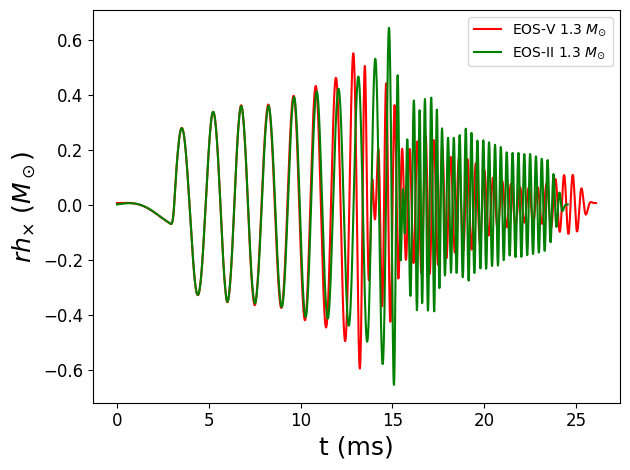

In [8]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

rh_fig,rh_axes = plt.subplots(1)

rh_axes.plot(rhc_a_1p3.t/203,rhc_a_1p3.y,label=r'EOS-V 1.3 $M_{\odot}$',color='Red')
#rh_axes.plot(rhc_b_1p3,label=r'$\alpha_B$ 1.3 M',color='blue')
rh_axes.plot(rhc_c_1p3.t/203,rhc_c_1p3.y,label=r'EOS-II 1.3 $M_{\odot}$',color='green')
#rh_axes.plot(rhc_d_1p3,label=r'$\alpha_D$ 1.3 M',color='black')
#rh_axes.plot(rhc_e_1p3,label=r'$\alpha_E$ 1.3 M',color = 'purple')
rh_axes.set_xlabel(r't (ms)',fontsize=axes_label_fontsize)
rh_axes.set_ylabel(r'$rh_{\times}$ ($M_\odot$)',fontsize=axes_label_fontsize)
rh_axes.legend()
rh_axes.tick_params(labelsize=tick_label_fontsize)
rh_fig.tight_layout()
# rh_fig.savefig('./Figures/Final_Paper_Figs/rhc_fig.pdf',format='pdf',dpi=300)

# np.savetxt('../Figure_Data/GW/rhc_eos_V_1p3.txt',np.asarray(list(zip(rhc_a_1p3.t,rhc_a_1p3.y))))
# np.savetxt('../Figure_Data/GW/rhc_eos_IV_1p3.txt',np.asarray(list(zip(rhc_e_1p3.t,rhc_e_1p3.y))))
# np.savetxt('../Figure_Data/GW/rhc_eos_III_1p3.txt',np.asarray(list(zip(rhc_b_1p3.t,rhc_b_1p3.y))))
# np.savetxt('../Figure_Data/GW/rhc_eos_II_1p3.txt',np.asarray(list(zip(rhc_c_1p3.t,rhc_c_1p3.y))))
# np.savetxt('../Figure_Data/GW/rhc_eos_I_1p3.txt',np.asarray(list(zip(rhc_d_1p3.t,rhc_d_1p3.y))))



In [9]:
t_mrg_1p3_A = rhp_a_1p3.t[np.argmax(np.abs(rhp_a_1p3.y))]/203
t_mrg_1p3_C = rhp_c_1p3.t[np.argmax(np.abs(rhp_c_1p3.y))]/203

print(t_mrg_1p3_A)
print(t_mrg_1p3_C)

13.052216748768473
14.95960591133005


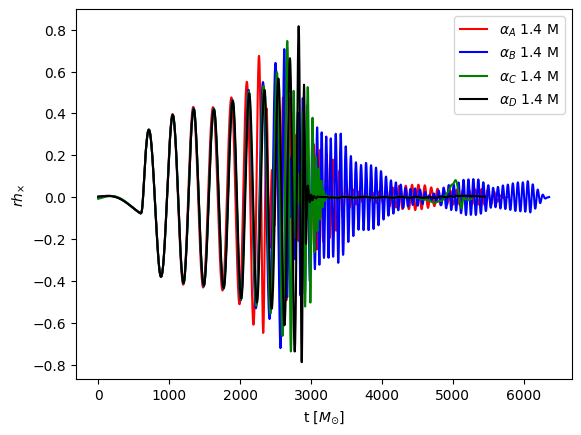

FileNotFoundError: [Errno 2] No such file or directory: '../Figure_Data/GW/rhc_eos_V_1p4.txt'

In [10]:
plt.plot(rhc_a,label=r'$\alpha_A$ 1.4 M',color = 'red')
plt.plot(rhc_b,label=r'$\alpha_B$ 1.4 M',color = 'blue')
plt.plot(rhc_c,label=r'$\alpha_C$ 1.4 M',color = 'green')
plt.plot(rhc_d,label=r'$\alpha_D$ 1.4 M',color= 'black')
plt.legend()
plt.xlabel(r't [$M_{\odot}$]')
plt.ylabel(r'$rh_{\times}$ ')
plt.show()

np.savetxt('../Figure_Data/GW/rhc_eos_V_1p4.txt',np.asarray(list(zip(rhc_a.t,rhc_a.y))))
np.savetxt('../Figure_Data/GW/rhc_eos_IV_1p4.txt',np.asarray(list(zip(rhc_e.t,rhc_e.y))))
np.savetxt('../Figure_Data/GW/rhc_eos_III_1p4.txt',np.asarray(list(zip(rhc_b.t,rhc_b.y))))
np.savetxt('../Figure_Data/GW/rhc_eos_II_1p4.txt',np.asarray(list(zip(rhc_c.t,rhc_c.y))))
np.savetxt('../Figure_Data/GW/rhc_eos_I_1p4.txt',np.asarray(list(zip(rhc_d.t,rhc_d.y))))


In [10]:
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p4/hp.txt',np.column_stack((rhp_a.t,rhp_a.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p4/hp.txt',np.column_stack((rhp_b.t,rhp_b.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p4/hp.txt',np.column_stack((rhp_c.t,rhp_c.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p4/hp.txt',np.column_stack((rhp_d.t,rhp_d.y)),header='t[M]   rh_plus')

np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p4/hc.txt',np.column_stack((rhc_a.t,rhc_a.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p4/hc.txt',np.column_stack((rhc_b.t,rhc_b.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p4/hc.txt',np.column_stack((rhc_c.t,rhc_c.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p4/hc.txt',np.column_stack((rhc_d.t,rhc_d.y)),header='t[M]   rh_cross')

np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p3/hp.txt',np.column_stack((rhp_a.t,rhp_a.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p3/hp.txt',np.column_stack((rhp_b.t,rhp_b.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p3/hp.txt',np.column_stack((rhp_c.t,rhp_c.y)),header='t[M]   rh_plus')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p3/hp.txt',np.column_stack((rhp_d.t,rhp_d.y)),header='t[M]   rh_plus')

np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p3/hc.txt',np.column_stack((rhc_a_1p3.t,rhc_a_1p3.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p3/hc.txt',np.column_stack((rhc_b_1p3.t,rhc_b_1p3.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p3/hc.txt',np.column_stack((rhc_c_1p3.t,rhc_c_1p3.y)),header='t[M]   rh_cross')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p3/hc.txt',np.column_stack((rhc_d_1p3.t,rhc_d_1p3.y)),header='t[M]   rh_cross')

In [30]:
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p4/EGW_Cumalitive.txt',np.column_stack((alpha_a_energy.t,alpha_a_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p4/EGW_Cumalitive.txt',np.column_stack((alpha_b_energy.t,alpha_b_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p4/EGW_Cumalitive.txt',np.column_stack((alpha_c_energy.t,alpha_c_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p4/EGW_Cumalitive.txt',np.column_stack((alpha_d_energy.t,alpha_d_energy.y)),header='t[M]     E_GW_Cum[M]')

np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p3/EGW_Cumalitive.txt',np.column_stack((alpha_a_1p3_energy.t,alpha_a_1p3_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p3/EGW_Cumalitive.txt',np.column_stack((alpha_b_1p3_energy.t,alpha_b_1p3_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p3/EGW_Cumalitive.txt',np.column_stack((alpha_c_1p3_energy.t,alpha_c_1p3_energy.y)),header='t[M]     E_GW_Cum[M]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p3/EGW_Cumalitive.txt',np.column_stack((alpha_d_1p3_energy.t,alpha_d_1p3_energy.y)),header='t[M]     E_GW_Cum[M]')


In [32]:
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p4/Jz_GW_Cumalitive.txt',np.column_stack((alpha_a_ang_mom.t,alpha_a_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p4/Jz_GW_Cumalitive.txt',np.column_stack((alpha_b_ang_mom.t,alpha_b_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p4/Jz_GW_Cumalitive.txt',np.column_stack((alpha_c_ang_mom.t,alpha_c_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p4/Jz_GW_Cumalitive.txt',np.column_stack((alpha_d_ang_mom.t,alpha_d_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')

np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_A/1p3/Jz_GW_Cumalitive.txt',np.column_stack((alpha_a_1p3_ang_mom.t,alpha_a_1p3_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_B/1p3/Jz_GW_Cumalitive.txt',np.column_stack((alpha_b_1p3_ang_mom.t,alpha_b_1p3_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_C/1p3/Jz_GW_Cumalitive.txt',np.column_stack((alpha_c_1p3_ang_mom.t,alpha_c_1p3_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')
np.savetxt('/home/jstroud/RVSS_Data_Processed/Alpha_D/1p3/Jz_GW_Cumalitive.txt',np.column_stack((alpha_d_1p3_ang_mom.t,alpha_d_1p3_ang_mom.y)),header='t[M]     Jz_GW_Cum[M^2]')

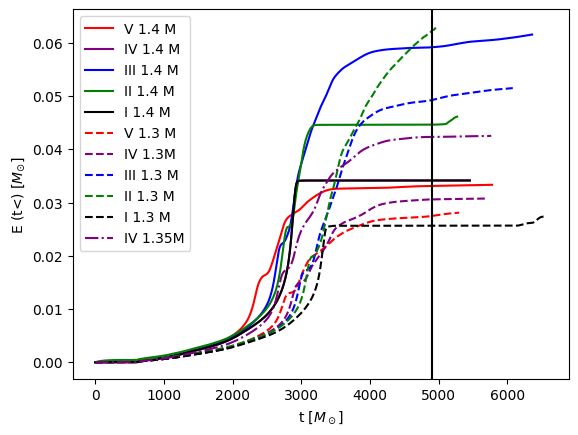

In [11]:
plt.plot(alpha_a_energy,label=r'V 1.4 M',color = 'red')
plt.plot(alpha_e_energy,label=r'IV 1.4 M',linestyle='-',color='purple')
plt.plot(alpha_b_energy,label=r'III 1.4 M',color='blue')
plt.plot(alpha_c_energy,label=r'II 1.4 M',color='green')
plt.plot(alpha_d_energy,label=r'I 1.4 M', color = 'black')
plt.plot(alpha_a_1p3_energy,label=r'V 1.3 M',linestyle = '--',color='red')
plt.plot(alpha_e_1p3_energy,label=r'IV 1.3M',linestyle = '--',color = 'purple')
plt.plot(alpha_b_1p3_energy,label=r'III 1.3 M',linestyle = '--',color='blue')
plt.plot(alpha_c_1p3_energy,label=r'II 1.3 M',linestyle='--',color = 'green')
plt.plot(alpha_d_1p3_energy,label=r'I 1.3 M',linestyle = '--',color='black')
plt.plot(alpha_e_1p35_energy,label=r'IV 1.35M',linestyle='-.',color = 'purple')

plt.axvline(x = 4900,color='black')
plt.ylabel(r'E (t<) [$M_{\odot}$]')
plt.xlabel(r't [$M_\odot$]')
plt.legend()
plt.show()

np.savetxt("../Figure_Data/GW/EOS_V_EGW_1p3.txt",list(zip(alpha_a_1p3_energy.t,alpha_a_1p3_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_V_EGW_1p4.txt",list(zip(alpha_a_energy.t,alpha_a_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_IV_EGW_1p3.txt",list(zip(alpha_e_1p3_energy.t,alpha_e_1p3_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_IV_EGW_1p4.txt",list(zip(alpha_e_energy.t,alpha_e_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_IV_EGW_1p35.txt",list(zip(alpha_e_1p35_energy.t,alpha_e_1p35_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_III_EGW_1p3.txt",list(zip(alpha_b_1p3_energy.t,alpha_b_1p3_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_III_EGW_1p4.txt",list(zip(alpha_b_energy.t,alpha_b_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_II_EGW_1p3.txt",list(zip(alpha_c_1p3_energy.t,alpha_c_1p3_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_II_EGW_1p4.txt",list(zip(alpha_c_energy.t,alpha_c_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_I_EGW_1p3.txt",list(zip(alpha_d_1p3_energy.t,alpha_d_1p3_energy.y)))
np.savetxt("../Figure_Data/GW/EOS_I_EGW_1p4.txt",list(zip(alpha_d_energy.t,alpha_d_energy.y)))

In [11]:
E_tot_GW_1p4 = []
E_tot_GW_1p3 = []
E_tot_GW_1p35 = []
E_tot_GW_1p5 = []

Lz_tot_GW_1p4 =[]
Lz_tot_GW_1p3 = []
Lz_tot_GW_1p35 = []
Lz_tot_GW_1p5 = []

t_cut = 4900
for i,t in enumerate(alpha_a_energy.t):
    if t > t_cut:
        E_tot_GW_1p4.append(alpha_a_energy.y[i])
        break
for i,t in enumerate(alpha_b_energy.t):
    if t > t_cut:
        E_tot_GW_1p4.append(alpha_b_energy.y[i])
        break
for i,t in enumerate(alpha_c_energy.t):
    if t > t_cut:
        E_tot_GW_1p4.append(alpha_c_energy.y[i])
        break
for i,t in enumerate(alpha_d_energy.t):
    if t > t_cut:
        E_tot_GW_1p4.append(alpha_d_energy.y[i])
        break
for i,t in enumerate(alpha_e_energy.t):
    if t > t_cut:
        E_tot_GW_1p4.append(alpha_e_energy.y[i])
        break

for i,t in enumerate(alpha_a_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p4.append(alpha_a_ang_mom.y[i])
        break
for i,t in enumerate(alpha_b_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p4.append(alpha_b_ang_mom.y[i])
        break
for i,t in enumerate(alpha_c_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p4.append(alpha_c_ang_mom.y[i])
        break
for i,t in enumerate(alpha_d_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p4.append(alpha_d_ang_mom.y[i])
        break
for i,t in enumerate(alpha_e_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p4.append(alpha_e_ang_mom.y[i])
        break

for i,t in enumerate(alpha_a_1p3_energy.t):
    if t > t_cut:
        E_tot_GW_1p3.append(alpha_a_1p3_energy.y[i])
        break
for i,t in enumerate(alpha_b_1p3_energy.t):
    if t > t_cut:
        E_tot_GW_1p3.append(alpha_b_1p3_energy.y[i])
        break
for i,t in enumerate(alpha_c_1p3_energy.t):
    if t > t_cut:
        E_tot_GW_1p3.append(alpha_c_1p3_energy.y[i])
        break
for i,t in enumerate(alpha_d_1p3_energy.t):
    if t > t_cut:
        E_tot_GW_1p3.append(alpha_d_1p3_energy.y[i])
        break

for i,t in enumerate(alpha_e_1p3_energy.t):
    if t > t_cut:
        E_tot_GW_1p3.append(alpha_e_1p3_energy.y[i])
        break

for i,t in enumerate(alpha_a_1p3_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p3.append(alpha_a_1p3_ang_mom.y[i])
        break
for i,t in enumerate(alpha_b_1p3_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p3.append(alpha_b_1p3_ang_mom.y[i])
        break
for i,t in enumerate(alpha_c_1p3_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p3.append(alpha_c_1p3_ang_mom.y[i])
        break
for i,t in enumerate(alpha_d_1p3_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p3.append(alpha_d_1p3_ang_mom.y[i])
        break
for i,t in enumerate(alpha_e_1p3_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p3.append(alpha_e_1p3_ang_mom.y[i])
        break

for i,t in enumerate(alpha_e_1p35_energy.t):
    if t > t_cut:
        E_tot_GW_1p35.append(alpha_e_1p35_energy.y[i])
        break

for i,t in enumerate(alpha_e_1p35_ang_mom.t):
    if t > t_cut:
        Lz_tot_GW_1p35.append(alpha_e_1p35_ang_mom.y[i])
        break

    
        


In [52]:
print(E_tot_GW_1p35)
print(Lz_tot_GW_1p35)

[0.042342577076412584]
[-1.5703722343609885]


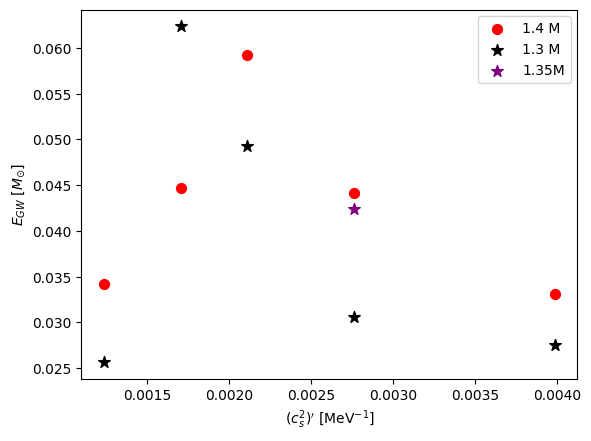

In [30]:
plt.scatter(alpha_list,E_tot_GW_1p4,s=50,label='1.4 M',color='red')
plt.scatter(alpha_list_1p3,E_tot_GW_1p3,s=75,label='1.3 M',color='black',marker='*')
plt.scatter(alpha_list[-1],E_tot_GW_1p35[0],s=75,label='1.35M',color='Purple',marker='*')
plt.ylabel(r'$E_{GW}$ [$M_{\odot}$]')
plt.xlabel(r"$(c_s^2)'$ [$\text{MeV}^{-1}$]")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/EGW_vs_alpha.pdf',format='pdf',dpi=300)
plt.show()

np.savetxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p3.txt',np.asanyarray(list(zip(alpha_list_1p3,E_tot_GW_1p3))))
np.savetxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p35.txt',np.asanyarray(list(zip(alpha_list,E_tot_GW_1p35))))
np.savetxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p4.txt',np.asanyarray(list(zip(alpha_list,E_tot_GW_1p4))))

FileNotFoundError: [Errno 2] No such file or directory: '/home/jstroud/J_GW_vs_alpha.pdf'

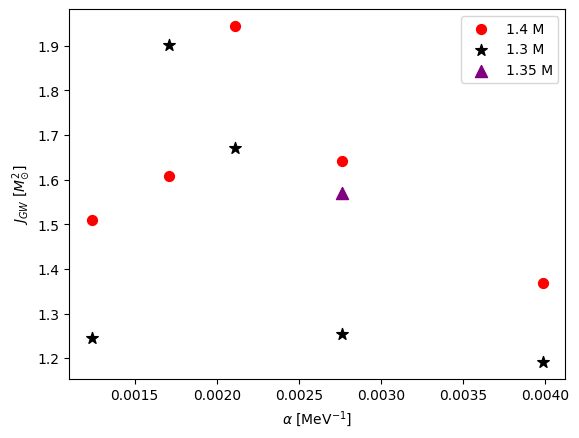

In [31]:
plt.scatter(alpha_list,-1*np.asarray(Lz_tot_GW_1p4),s=50,label='1.4 M',color='red')
plt.scatter(alpha_list_1p3,-1*np.asarray(Lz_tot_GW_1p3),s=75,label='1.3 M',color='black',marker='*')
plt.scatter(alpha_list[-1],-1*np.asarray(Lz_tot_GW_1p35)[0],s=75,label='1.35 M',color='purple',marker='^')
plt.ylabel(r'$J_{GW}$ [$M_{\odot}^2$]')
plt.xlabel(r'$\alpha$ [$\text{MeV}^{-1}$]')
plt.legend()
plt.savefig('/home/jstroud/J_GW_vs_alpha.pdf',format='pdf')
plt.show()

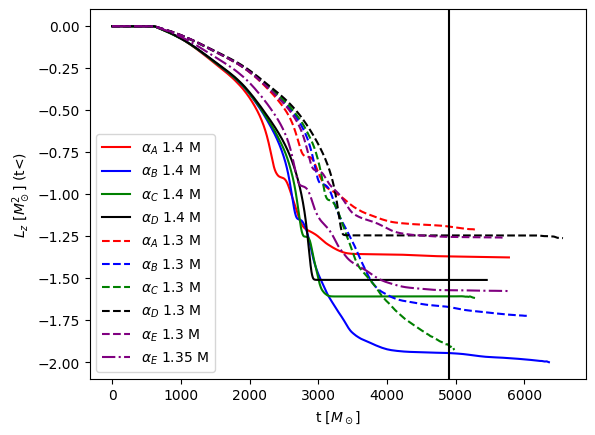

In [32]:
plt.plot(alpha_a_ang_mom,label=r'$\alpha_A$ 1.4 M',color = 'red')
plt.plot(alpha_b_ang_mom,label=r'$\alpha_B$ 1.4 M',color = 'blue')
plt.plot(alpha_c_ang_mom,label=r'$\alpha_C$ 1.4 M',color = 'green')
plt.plot(alpha_d_ang_mom,label=r'$\alpha_D$ 1.4 M',color = 'black')
plt.plot(alpha_a_1p3_ang_mom,label=r'$\alpha_A$ 1.3 M',color='red',linestyle='--')
plt.plot(alpha_b_1p3_ang_mom,label=r'$\alpha_B$ 1.3 M',color='blue',linestyle='--')
plt.plot(alpha_c_1p3_ang_mom,label=r'$\alpha_C$ 1.3 M',color = 'green',linestyle='--')
plt.plot(alpha_d_1p3_ang_mom,label=r'$\alpha_D$ 1.3 M',color = 'black',linestyle='--')
plt.plot(alpha_e_1p3_ang_mom,label=r'$\alpha_E$ 1.3 M', color = 'purple', linestyle = '--')
plt.plot(alpha_e_1p35_ang_mom,label=r'$\alpha_E$ 1.35 M', color = 'purple',linestyle = '-.')
plt.axvline(x = 4900,color='black')
plt.ylabel(r'$L_z$ [$M_\odot^2$] (t<)')
plt.xlabel(r't [$M_\odot$]')
plt.legend()

In [33]:
phase_a = np.unwrap(np.arctan2(np.real(alpha_a_strain.y),np.imag(alpha_a_strain.y)))
phase_b = np.unwrap(np.arctan2(np.real(alpha_b_strain.y),np.imag(alpha_b_strain.y)))
phase_c = np.unwrap(np.arctan2(np.real(alpha_c_strain.y),np.imag(alpha_c_strain.y)))
phase_d = np.unwrap(np.arctan2(np.real(alpha_d_strain.y),np.imag(alpha_d_strain.y)))

freq_inst_a = (1/(2*np.pi))*np.gradient(phase_a,alpha_a_strain.t)
freq_inst_b = (1/(2*np.pi))*np.gradient(phase_b,alpha_b_strain.t)
freq_inst_c = (1/(2*np.pi))*np.gradient(phase_c,alpha_c_strain.t)
freq_inst_d = (1/(2*np.pi))*np.gradient(phase_d,alpha_d_strain.t)

###########################################################################################
phase_a_1p3 = np.unwrap(np.arctan2(np.real(alpha_a_1p3_strain.y),np.imag(alpha_a_1p3_strain.y)))
phase_b_1p3 = np.unwrap(np.arctan2(np.real(alpha_b_1p3_strain.y),np.imag(alpha_b_1p3_strain.y)))
phase_c_1p3 = np.unwrap(np.arctan2(np.real(alpha_c_1p3_strain.y),np.imag(alpha_c_1p3_strain.y)))
phase_d_1p3 = np.unwrap(np.arctan2(np.real(alpha_d_1p3_strain.y),np.imag(alpha_d_1p3_strain.y)))
phase_e_1p3 = np.unwrap(np.arctan2(np.real(alpha_e_1p3_strain.y),np.imag(alpha_e_1p3_strain.y)))

freq_inst_a_1p3 = (1/(2*np.pi))*np.gradient(phase_a_1p3,alpha_a_1p3_strain.t)
freq_inst_b_1p3 = (1/(2*np.pi))*np.gradient(phase_b_1p3,alpha_b_1p3_strain.t)
freq_inst_c_1p3 = (1/(2*np.pi))*np.gradient(phase_c_1p3,alpha_c_1p3_strain.t)
freq_inst_d_1p3 = (1/(2*np.pi))*np.gradient(phase_d_1p3,alpha_d_1p3_strain.t)
freq_inst_e_1p3 = (1/(2*np.pi))*np.gradient(phase_e_1p3,alpha_e_1p3_strain.t)


############################################################################################
#phase_a_1p5 = np.unwrap(np.arctan2(np.real(alpha_a_1p5_strain.y),np.imag(alpha_a_1p5_strain.y)))
#phase_b_1p3 = np.unwrap(np.arctan2(np.real(alpha_b_1p3_strain.y),np.imag(alpha_b_1p3_strain.y)))
#phase_c_1p3 = np.unwrap(np.arctan2(np.real(alpha_c_1p3_strain.y),np.imag(alpha_c_1p3_strain.y)))
#phase_d_1p3 = np.unwrap(np.arctan2(np.real(alpha_d_1p3_strain.y),np.imag(alpha_d_1p3_strain.y)))

#freq_inst_a_1p5 = (1/(2*np.pi))*np.gradient(phase_a_1p5,alpha_a_1p5_strain.t)
#freq_inst_b_1p3 = (1/(2*np.pi))*np.gradient(phase_b_1p3,alpha_b_1p3_strain.t)
#freq_inst_c_1p3 = (1/(2*np.pi))*np.gradient(phase_c_1p3,alpha_c_1p3_strain.t)
#freq_inst_d_1p3 = (1/(2*np.pi))*np.gradient(phase_d_1p3,alpha_d_1p3_strain.t)


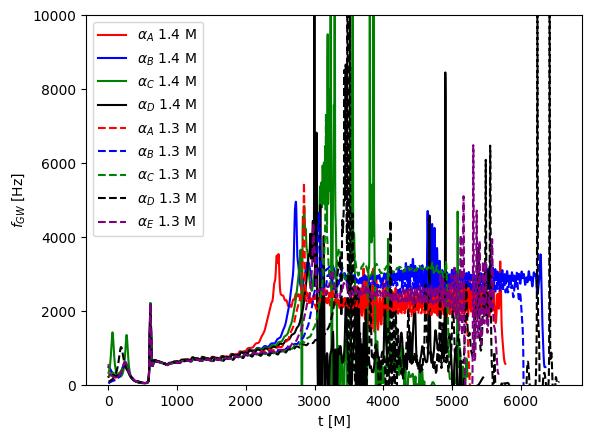

In [34]:
plt.xlabel('t [M]')
plt.ylabel(r'$f_{GW}$ [Hz]')
plt.plot(alpha_a_strain.t,freq_inst_a*freq_code_u_to_hz,label=r'$\alpha_A$ 1.4 M',color='red')
plt.plot(alpha_b_strain.t,freq_inst_b*freq_code_u_to_hz,label=r'$\alpha_B$ 1.4 M',color='blue')
plt.plot(alpha_c_strain.t,freq_inst_c*freq_code_u_to_hz,label=r'$\alpha_C$ 1.4 M',color = 'green')
plt.plot(alpha_d_strain.t,freq_inst_d*freq_code_u_to_hz,label=r'$\alpha_D$ 1.4 M',color = 'black')

plt.plot(alpha_a_1p3_strain.t,freq_inst_a_1p3*freq_code_u_to_hz,label=r'$\alpha_A$ 1.3 M',color='red',linestyle='--')
plt.plot(alpha_b_1p3_strain.t,freq_inst_b_1p3*freq_code_u_to_hz,label=r'$\alpha_B$ 1.3 M',color='blue',linestyle='--')
plt.plot(alpha_c_1p3_strain.t,freq_inst_c_1p3*freq_code_u_to_hz,label=r'$\alpha_C$ 1.3 M',color = 'green',linestyle='--')
plt.plot(alpha_d_1p3_strain.t,freq_inst_d_1p3*freq_code_u_to_hz,label=r'$\alpha_D$ 1.3 M',color = 'black',linestyle='--')

plt.plot(alpha_e_1p3_strain.t,freq_inst_e_1p3*freq_code_u_to_hz,label=r'$\alpha_E$ 1.3 M',color = 'purple', linestyle = '--')

plt.gca().set_ylim([0,10000])
plt.legend()

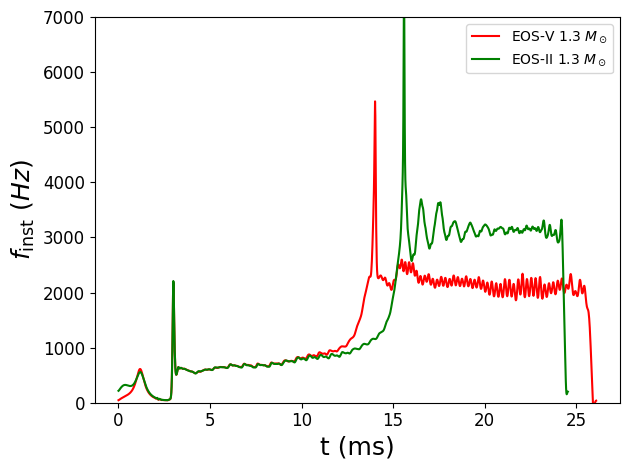

In [35]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

f_inst_fig,f_inst_axes = plt.subplots(1)
f_inst_axes.set_xlabel('t (ms)',fontsize=axes_label_fontsize)
f_inst_axes.set_ylabel(r'$f_{\text{inst}}~\left(Hz\right)$',fontsize=axes_label_fontsize)
#plt.plot(alpha_a_strain.t,freq_inst_a*freq_code_u_to_hz,label=r'$\alpha_A$ 1.4 M',color='red')
#plt.plot(alpha_b_strain.t,freq_inst_b*freq_code_u_to_hz,label=r'$\alpha_B$ 1.4 M',color='blue')
f_inst_axes.plot(alpha_a_1p3_strain.t*(1/203),freq_inst_a_1p3*freq_code_u_to_hz,label=r'EOS-V 1.3 $M_\odot$',color='red')
#plt.plot(alpha_b_1p3_strain.t,freq_inst_b_1p3*freq_code_u_to_hz,label=r'$\alpha_B$ 1.3 M',color='blue',linestyle='--')
f_inst_axes.plot(alpha_c_1p3_strain.t*(1/203),freq_inst_c_1p3*freq_code_u_to_hz,label=r'EOS-II 1.3 $M_\odot$',color='green')
#plt.plot(alpha_e_1p3_strain.t,freq_inst_e_1p3*freq_code_u_to_hz,label=r'$\alpha_E$ 1.3 M',color = 'purple', linestyle = '--')
f_inst_axes.set_ylim([0,7000])
f_inst_axes.tick_params(labelsize=tick_label_fontsize)
f_inst_axes.legend()
f_inst_fig.tight_layout()
f_inst_fig.savefig('./Figures/Final_Paper_Figs/f_inst_t.pdf',format='pdf',dpi=300)


In [36]:
hp_a = rhp_a/r_ext
hc_a = rhc_a/r_ext

hp_b = rhp_b/r_ext
hc_b = rhc_b/r_ext

hp_c = rhp_c/r_ext
hc_c = rhc_c/r_ext

hp_d = rhp_d/r_ext
hc_d = rhc_d/r_ext

hp_e = rhp_e/r_ext
hc_e = rhc_e/r_ext

hp_a_ft = hp_a.to_FrequencySeries()
hc_a_ft = hc_a.to_FrequencySeries()

hp_b_ft = hp_b.to_FrequencySeries()
hc_b_ft = hc_b.to_FrequencySeries()

hp_c_ft = hp_c.to_FrequencySeries()
hc_c_ft = hc_c.to_FrequencySeries()

hc_d_ft = hc_d.to_FrequencySeries()
hp_d_ft = hp_d.to_FrequencySeries()

hc_e_ft = hc_e.to_FrequencySeries()
hp_e_ft = hp_e.to_FrequencySeries()


###########################################
hp_a_1p3 = rhp_a_1p3/r_ext
hc_a_1p3 = rhc_a_1p3/r_ext

hp_b_1p3 = rhp_b_1p3/r_ext
hc_b_1p3 = rhc_b_1p3/r_ext

hp_c_1p3 = rhp_c_1p3/r_ext
hc_c_1p3 = rhc_c_1p3/r_ext

hp_d_1p3 = rhp_d_1p3/r_ext
hc_d_1p3 = rhc_d_1p3/r_ext

hp_e_1p3 = rhp_e_1p3/r_ext
hc_e_1p3 = rhc_e_1p3/r_ext

hp_a_ft_1p3 = hp_a_1p3.to_FrequencySeries()
hc_a_ft_1p3 = hc_a_1p3.to_FrequencySeries()

hp_b_ft_1p3 = hp_b_1p3.to_FrequencySeries()
hc_b_ft_1p3 = hc_b_1p3.to_FrequencySeries()

hp_c_ft_1p3 = hp_c_1p3.to_FrequencySeries()
hc_c_ft_1p3 = hc_c_1p3.to_FrequencySeries()

hc_d_ft_1p3 = hc_d_1p3.to_FrequencySeries()
hp_d_ft_1p3 = hp_d_1p3.to_FrequencySeries()

hc_e_ft_1p3 = hc_e_1p3.to_FrequencySeries()
hp_e_ft_1p3 = hp_e_1p3.to_FrequencySeries()

hp_e_1p35 = rhp_e_1p35/r_ext
hc_e_1p35 = rhc_e_1p35/r_ext

hc_e_ft_1p35 = hc_e_1p35.to_FrequencySeries()
hp_e_ft_1p35 = hp_e_1p35.to_FrequencySeries()



In [37]:
h_tild_a = np.sqrt(((hc_a_ft.real()**2 + hc_a_ft.imag()**2) + (hp_a_ft.real()**2 + hp_a_ft.imag()**2))/2)
h_tild_b = np.sqrt(((hc_b_ft.real()**2 + hc_b_ft.imag()**2) + (hp_b_ft.real()**2 + hp_b_ft.imag()**2))/2)
h_tild_c = np.sqrt(((hc_c_ft.real()**2 + hc_c_ft.imag()**2) + (hp_c_ft.real()**2 + hp_c_ft.imag()**2))/2)
h_tild_d = np.sqrt(((hc_d_ft.real()**2 + hc_d_ft.imag()**2) + (hp_d_ft.real()**2 + hp_d_ft.imag()**2))/2)
h_tild_e = np.sqrt(((hc_e_ft.real()**2 + hc_e_ft.imag()**2) + (hp_e_ft.real()**2 + hp_e_ft.imag()**2))/2)


####
h_tild_a_1p3 = np.sqrt(((hc_a_ft_1p3.real()**2 + hc_a_ft_1p3.imag()**2) + (hp_a_ft_1p3.real()**2 + hp_a_ft_1p3.imag()**2))/2)
h_tild_b_1p3 = np.sqrt(((hc_b_ft_1p3.real()**2 + hc_b_ft_1p3.imag()**2) + (hp_b_ft_1p3.real()**2 + hp_b_ft_1p3.imag()**2))/2)
h_tild_c_1p3 = np.sqrt(((hc_c_ft_1p3.real()**2 + hc_c_ft_1p3.imag()**2) + (hp_c_ft_1p3.real()**2 + hp_c_ft_1p3.imag()**2))/2)
h_tild_d_1p3 = np.sqrt(((hc_d_ft_1p3.real()**2 + hc_d_ft_1p3.imag()**2) + (hp_d_ft_1p3.real()**2 + hp_d_ft_1p3.imag()**2))/2)
h_tild_e_1p3 = np.sqrt(((hc_e_ft_1p3.real()**2 + hc_e_ft_1p3.imag()**2) + (hp_e_ft_1p3.real()**2 + hp_e_ft_1p3.imag()**2))/2)
####

h_tild_e_1p35 = np.sqrt(((hc_e_ft_1p35.real()**2 + hc_e_ft_1p35.imag()**2) + (hp_e_ft_1p35.real()**2)/2))

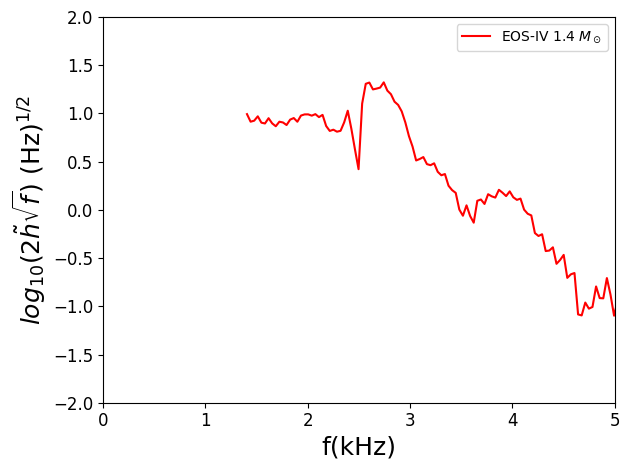

In [44]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

asd_fig,asd_axes = plt.subplots(1)
asd_axes.set_xlim([0,5])
asd_axes.set_ylim([-2,2])
asd_axes.set_xlabel('f(kHz)',fontsize=axes_label_fontsize)
asd_axes.set_ylabel(r'$log_{10}(2\tilde{h}\sqrt{f})~\left(\text{Hz}\right)^{1/2}$',fontsize=axes_label_fontsize)


asd_axes.plot(h_tild_e.f[40:]*freq_code_u_to_hz/1000,np.log10(2*h_tild_e.fft[40:]*np.sqrt(h_tild_e.f[40:]*freq_code_u_to_hz)),'red',label=r'EOS-IV 1.4 $M_\odot$')
# asd_axes.plot(h_tild_c_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_c_1p3.fft*np.sqrt(h_tild_c_1p3.f*freq_code_u_to_hz)),'green',label=r'EOS-II 1.3 $M_\odot$')
asd_axes.legend()
asd_axes.tick_params(labelsize=tick_label_fontsize)
asd_fig.tight_layout()
# asd_fig.savefig('./Figures/Final_Paper_Figs/asd_fig.pdf',format='pdf',dpi=300)

# np.savetxt('../Figure_Data/GW/EOS_V_asd_1p4.txt',np.asarray(list(zip(h_tild_a.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_a.fft*np.sqrt(h_tild_a.f))))))
# np.savetxt('../Figure_Data/GW/EOS_III_asd_1p4.txt',np.asarray(list(zip(h_tild_b.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_b.fft*np.sqrt(h_tild_b.f))))))

# np.savetxt('../Figure_Data/GW/EOS_V_asd_1p3.txt',np.asarray(list(zip(h_tild_a_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_a_1p3.fft*np.sqrt(h_tild_a_1p3.f))))))
# np.savetxt('../Figure_Data/GW/EOS_IV_asd_1p3.txt',np.asarray(list(zip(h_tild_e_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_e_1p3.fft*np.sqrt(h_tild_e_1p3.f))))))
# np.savetxt('../Figure_Data/GW/EOS_III_asd_1p3.txt',np.asarray(list(zip(h_tild_b_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_b_1p3.fft*np.sqrt(h_tild_b_1p3.f))))))
# np.savetxt('../Figure_Data/GW/EOS_II_asd_1p3.txt',np.asarray(list(zip(h_tild_c_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_c_1p3.fft*np.sqrt(h_tild_c_1p3.f))))))




/scratch/jstroud/job_43540564/ipykernel_3105328/2230260667.py:11: RuntimeWarning: divide by zero encountered in log10
  plt.plot(h_tild_e_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_e_1p3.fft*np.sqrt(h_tild_e_1p3.f)),'purple',label=r'$\alpha_E$ 1.3 M',linestyle = '--')


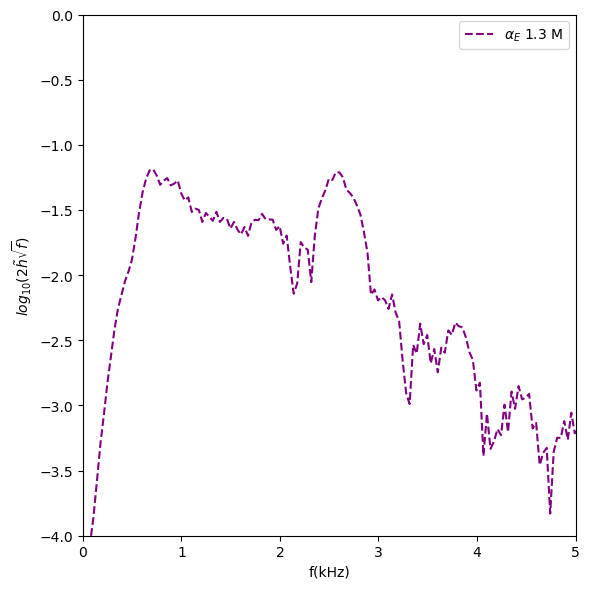

In [ ]:
plt.figure(figsize=(6,6))
plt.xlim([0,5])
plt.ylim([-4,0])
plt.xlabel('f(kHz)')
plt.ylabel(r'$log_{10}(2\tilde{h}\sqrt{f} )$')
plt.plot(h_tild_a.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_a.fft*np.sqrt(h_tild_a.f)),'red',label=r'$\alpha_A$ 1.4 M')
plt.plot(h_tild_b.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_b.fft*np.sqrt(h_tild_b.f)),'blue',label=r'$\alpha_B$ 1.4 M')
plt.plot(h_tild_a_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_a_1p3.fft*np.sqrt(h_tild_a_1p3.f)),'red',label=r'$\alpha_A$ 1.3 M',linestyle='--')
plt.plot(h_tild_b_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_b_1p3.fft*np.sqrt(h_tild_b_1p3.f)),'blue',label=r'$\alpha_B$ 1.3 M',linestyle='--')
plt.plot(h_tild_c_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_c_1p3.fft*np.sqrt(h_tild_c_1p3.f)),'green',label=r'$\alpha_C$ 1.3 M',linestyle='--')
plt.plot(h_tild_e_1p3.f*freq_code_u_to_hz/1000,np.log10(2*h_tild_e_1p3.fft*np.sqrt(h_tild_e_1p3.f)),'purple',label=r'$\alpha_E$ 1.3 M',linestyle = '--')
plt.tight_layout()
plt.legend()

In [48]:
Alpha_a_1p4_f2 = h_tild_a.f[np.argmax(np.log10(2*h_tild_a.fft*np.sqrt(h_tild_a.f)))]*freq_code_u_to_hz/1000
Alpha_b_1p4_f2 = h_tild_b.f[np.argmax(np.log10(2*h_tild_b.fft*np.sqrt(h_tild_b.f)))]*freq_code_u_to_hz/1000
Alpha_c_1p4_f2 = h_tild_c.f[np.argmax(np.log10(2*h_tild_c.fft*np.sqrt(h_tild_c.f)))]*freq_code_u_to_hz/1000
Alpha_d_1p4_f2 = h_tild_d.f[np.argmax(np.log10(2*h_tild_d.fft*np.sqrt(h_tild_d.f)))]*freq_code_u_to_hz/1000
Alpha_e_1p4_f2 = h_tild_e.f[np.argmax(np.log10(2*h_tild_e.fft[40:]*np.sqrt(h_tild_e.f[40:])))+40]*freq_code_u_to_hz/1000

f2_list_1p4 = [Alpha_a_1p4_f2,Alpha_b_1p4_f2,Alpha_c_1p4_f2,Alpha_d_1p4_f2,Alpha_e_1p4_f2]
print(f2_list_1p4)
Alpha_a_1p3_f2 = h_tild_a_1p3.f[np.argmax(np.log10(2*h_tild_a_1p3.fft*np.sqrt(h_tild_a_1p3.f)))]*freq_code_u_to_hz/1000
Alpha_b_1p3_f2 = h_tild_b_1p3.f[np.argmax(np.log10(2*h_tild_b_1p3.fft*np.sqrt(h_tild_b_1p3.f)))]*freq_code_u_to_hz/1000
Alpha_c_1p3_f2 = h_tild_c_1p3.f[np.argmax(np.log10(2*h_tild_c_1p3.fft*np.sqrt(h_tild_c_1p3.f)))]*freq_code_u_to_hz/1000
Alpha_d_1p3_f2 = h_tild_d_1p3.f[np.argmax(np.log10(2*h_tild_d_1p3.fft*np.sqrt(h_tild_d_1p3.f)))]*freq_code_u_to_hz/1000
Alpha_e_1p3_f2 = h_tild_e_1p3.f[np.argmax(np.log10(2*h_tild_e_1p3.fft[40:]*np.sqrt(h_tild_e_1p3.f[40:]))) + 40]*freq_code_u_to_hz/1000
Alpha_e_1p35_f2 = h_tild_e_1p35.f[np.argmax(np.log10(2*h_tild_e_1p35.fft[40:]*np.sqrt(h_tild_e_1p35.f[40:]))) + 40]*freq_code_u_to_hz/1000


f2_list_1p3 = [Alpha_a_1p3_f2,Alpha_b_1p3_f2,Alpha_c_1p3_f2,Alpha_d_1p3_f2,Alpha_e_1p3_f2]
M_f2_list_1p3 = [(2.6)*Alpha_a_1p3_f2*1000/freq_code_u_to_hz,
                 (2.6)*Alpha_b_1p3_f2*1000/freq_code_u_to_hz,
                 (2.6)*Alpha_c_1p3_f2*1000/freq_code_u_to_hz,
                 (2.6)*Alpha_d_1p3_f2*1000/freq_code_u_to_hz,
                 (2.6)*Alpha_e_1p3_f2*1000/freq_code_u_to_hz]
M_f2_list_1p4 = [(2.8)*Alpha_a_1p4_f2*1000/freq_code_u_to_hz,
                 (2.8)*Alpha_b_1p4_f2*1000/freq_code_u_to_hz,
                 (2.8)*Alpha_c_1p4_f2*1000/freq_code_u_to_hz,
                 (2.8)*Alpha_d_1p4_f2*1000/freq_code_u_to_hz]
print(f2_list_1p3)

[2.3534399224806197, 2.935739436619718, 0.7318230115361263, 0.7441348973607038, 2.7428630820399107]
[0.6895380434782608, 2.837993421052632, 3.175946726572529, 0.71104410331384, 2.6031127037661603]


/tmp/ipykernel_11241/931741591.py:1: RuntimeWarning: divide by zero encountered in log10
  Alpha_a_1p4_f2 = h_tild_a.f[np.argmax(np.log10(2*h_tild_a.fft*np.sqrt(h_tild_a.f)))]*freq_code_u_to_hz/1000
/tmp/ipykernel_11241/931741591.py:2: RuntimeWarning: divide by zero encountered in log10
  Alpha_b_1p4_f2 = h_tild_b.f[np.argmax(np.log10(2*h_tild_b.fft*np.sqrt(h_tild_b.f)))]*freq_code_u_to_hz/1000
/tmp/ipykernel_11241/931741591.py:3: RuntimeWarning: divide by zero encountered in log10
  Alpha_c_1p4_f2 = h_tild_c.f[np.argmax(np.log10(2*h_tild_c.fft*np.sqrt(h_tild_c.f)))]*freq_code_u_to_hz/1000
/tmp/ipykernel_11241/931741591.py:4: RuntimeWarning: divide by zero encountered in log10
  Alpha_d_1p4_f2 = h_tild_d.f[np.argmax(np.log10(2*h_tild_d.fft*np.sqrt(h_tild_d.f)))]*freq_code_u_to_hz/1000
/tmp/ipykernel_11241/931741591.py:9: RuntimeWarning: divide by zero encountered in log10
  Alpha_a_1p3_f2 = h_tild_a_1p3.f[np.argmax(np.log10(2*h_tild_a_1p3.fft*np.sqrt(h_tild_a_1p3.f)))]*freq_code_u_to_h

In [46]:
print(Alpha_e_1p35_f2)

2640.2955049944503


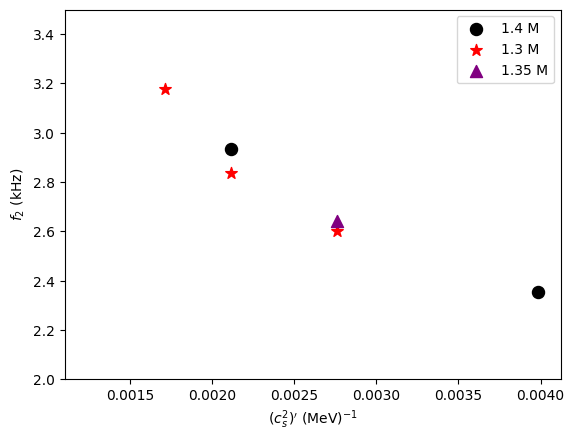

In [52]:
plt.scatter(alpha_list,f2_list_1p4,s=75,marker='o',label='1.4 M', color = 'black')
plt.scatter(alpha_list_1p3,f2_list_1p3,s=75,marker='*',label='1.3 M', color= 'red')
plt.scatter(alpha_list[-1],Alpha_e_1p35_f2,s=75,marker='^',label='1.35 M',color= 'purple')
plt.ylim([2.0,3.5])
plt.xlabel(r"$(c_s^2)'\text{ (MeV)}^{-1}$")
plt.ylabel(r"$f_2 \text{ (kHz)}$")
plt.legend()

np.savetxt('../Figure_Data/GW/f2_vs_cs2prime_1p4.txt',np.asarray(list(zip(alpha_list,f2_list_1p4))))
np.savetxt('../Figure_Data/GW/f2_vs_cs2prime_1p3.txt',np.asarray(list(zip(alpha_list_1p3,f2_list_1p3))))
np.savetxt('../Figure_Data/GW/f2_vs_cs2prime_1p35.txt',np.asarray([alpha_list[-1],Alpha_e_1p35_f2]))

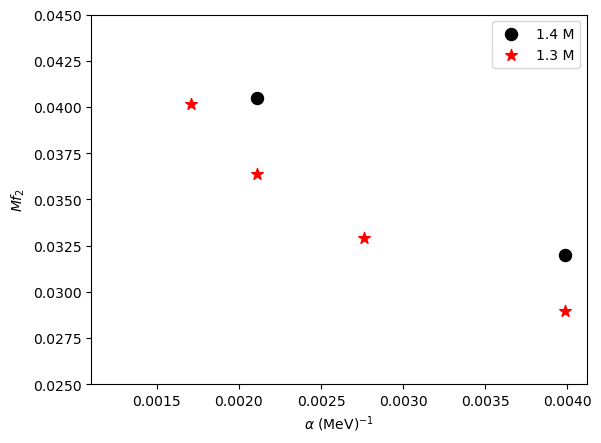

In [40]:
plt.scatter(alpha_list,M_f2_list_1p4,s=75,marker='o',label='1.4 M', color = 'black')
plt.scatter(alpha_list_1p3,M_f2_list_1p3,s=75,marker='*',label='1.3 M', color= 'red')
plt.ylim([0.025,0.045])
plt.xlabel(r'$\alpha\text{ (MeV)}^{-1}$')
plt.ylabel(r'$Mf_2$')
plt.legend()
plt.savefig('/home/jstroud/Mf2_alpha.pdf',format='pdf')

In [9]:
base_dir_a_1p4 = '/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M'
base_dir_b_1p4 = '/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M'
base_dir_c_1p4 = '/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M'
base_dir_d_1p4 = '/mnt/John_Backup/RVSS Data/Model_D/1p4M_1p4M'
base_dir_e_1p4 = '/mnt/John_Backup/RVSS Data/Model_E/1p4M'

base_dir_a_1p3 = '/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M'
base_dir_b_1p3 = '/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M'
base_dir_c_1p3 = '/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M'
base_dir_d_1p3 = '/mnt/John_Backup/RVSS Data/Model_D/1p3M_1p3M'
base_dir_e_1p3 = '/mnt/John_Backup/RVSS Data/Model_E/1p3M'

base_dir_e_1p35 = '/mnt/John_Backup/RVSS Data/Model_E/1p35M'

data_dir_a_1p4 = sorted(glob.glob(os.path.join(base_dir_a_1p4,'rho_max/rho_max_0[0-9]*')))
data_dir_b_1p4 = sorted(glob.glob(os.path.join(base_dir_b_1p4,'rho_max/rho_max_0[0-9]*')))
data_dir_c_1p4 = sorted(glob.glob(os.path.join(base_dir_c_1p4,'rho_max/rho_max_0[0-9]*')))
data_dir_d_1p4 = sorted(glob.glob(os.path.join(base_dir_d_1p4,'rho_max/rho_max_0[0-9]*')))

data_dir_a_1p3 = sorted(glob.glob(os.path.join(base_dir_a_1p3,'rho_max/rho_max_0[0-9]*')))
data_dir_b_1p3 = sorted(glob.glob(os.path.join(base_dir_b_1p3,'rho_max/rho_max_0[0-9]*')))
data_dir_c_1p3 = sorted(glob.glob(os.path.join(base_dir_c_1p3,'rho_max/rho_max_0[0-9]*')))
data_dir_d_1p3 = sorted(glob.glob(os.path.join(base_dir_d_1p3,'rho_max/rho_max_0[0-9]*')))
data_dir_e_1p3 = sorted(glob.glob(os.path.join(base_dir_e_1p3,'rho_max/rho_max_0[0-9]*')))

data_dir_e_1p35 = sorted(glob.glob(os.path.join(base_dir_e_1p35,'rho_max/rho_max_0[0-9]*')))

data_dir_e_1p4 = sorted(glob.glob(os.path.join(base_dir_e_1p4,'rho_max/rho_max_0[0-9]*')))


rho_max_1p4M = [data_dir_a_1p4,data_dir_b_1p4,data_dir_c_1p4,data_dir_d_1p4,data_dir_e_1p4]
rho_max_1p3M = [data_dir_a_1p3,data_dir_b_1p3,data_dir_c_1p3,data_dir_d_1p3,data_dir_e_1p3]

In [10]:
rho_max_a_1p4 = []
rho_max_b_1p4 = []
rho_max_c_1p4 = []
rho_max_d_1p4 = []
rho_max_e_1p4 = []

rho_max_a_1p3 = []
rho_max_b_1p3 = []
rho_max_c_1p3 = []
rho_max_d_1p3 = []
rho_max_e_1p3 = []

rho_max_e_1p35 = []

rho_max_a_1p4_t = []
rho_max_b_1p4_t = []
rho_max_c_1p4_t = []
rho_max_d_1p4_t = []
rho_max_e_1p4_t = []

rho_max_a_1p3_t = []
rho_max_b_1p3_t = []
rho_max_c_1p3_t = []
rho_max_d_1p3_t = []
rho_max_e_1p3_t = []

rho_max_e_1p35_t = []


for file in data_dir_a_1p4:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_a_1p4_t:
            rho_max_a_1p4.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_a_1p4_t.append(line[1])
        else:
            continue

for file in data_dir_b_1p4:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_b_1p4_t:
            rho_max_b_1p4.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_b_1p4_t.append(line[1])
        else:
            continue

for file in data_dir_c_1p4:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_c_1p4_t:
            rho_max_c_1p4.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_c_1p4_t.append(line[1])
        else:
            continue

for file in data_dir_d_1p4:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_d_1p4_t:
            rho_max_d_1p4.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_d_1p4_t.append(line[1])
        else:
            continue


for file in data_dir_a_1p3:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_a_1p3_t:
            rho_max_a_1p3.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_a_1p3_t.append(line[1])
        else:
            continue

for file in data_dir_b_1p3:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_b_1p3_t:
            rho_max_b_1p3.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_b_1p3_t.append(line[1])
        else:
            continue

for file in data_dir_c_1p3:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_c_1p3_t:
            rho_max_c_1p3.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_c_1p3_t.append(line[1])
        else:
            continue

for file in data_dir_d_1p3:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_d_1p3_t:
            rho_max_d_1p3.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_d_1p3_t.append(line[1])
        else:
            continue
for file in data_dir_e_1p3:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_e_1p3_t:
            rho_max_e_1p3.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_e_1p3_t.append(line[1])
        else:
            continue
for file in data_dir_e_1p35:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_e_1p35_t:
            rho_max_e_1p35.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_e_1p35_t.append(line[1])
        else:
            continue
for file in data_dir_e_1p4:
    data = np.loadtxt(file,skiprows=6)
    for line in data:
        if line[1] not in rho_max_e_1p4_t:
            rho_max_e_1p4.append(line[2]*geometrized_code_to_nb_n0)
            rho_max_e_1p4_t.append(line[1])
            print(rho_max_e_1p4[-1])
        else:
            continue

0.36233188204807953
0.36251728437939246
0.36250194958142923
0.36246559150010815
0.36267716640569775
0.362599254167333
0.362560947704519
0.3622968843549851
0.3627086737810371
0.3603349035948056
0.36069204174909797
0.3621301859582674
0.3623039317224339
0.3621558548723353
0.36223034422904804
0.3622364568598124
0.36213889577215563
0.3621873392013293
0.3623184392012363
0.36241777500508787
0.36248522183441967
0.3625215468401031
0.3625524345089747
0.36251308752996764
0.3625333906172549
0.36259611817143583
0.3623458018925596
0.36194744142974966
0.36159344532505955
0.36164881985668684
0.36165871502682206
0.3616196659039596
0.3617099420050526
0.3618357528487386
0.362022957802582
0.3621903726242471
0.3623455751145641
0.3624509502319506
0.3623370821705893
0.36232042831001054
0.36225085527725
0.362288616918112
0.3625130027004307
0.3627342925675526
0.362745315665951
0.3624025638224381
0.362017105594237
0.3617381005754033
0.3616014416910158
0.3616214547267325
0.3616559459290837
0.36165334424457163
0.

In [11]:
maximum_n_V_1p4 = max(rho_max_a_1p4)
maximum_n_IV_1p4 = max(rho_max_e_1p4)
maximum_n_III_1p4 = max(rho_max_b_1p4)
maximum_n_II_1p3 = max(rho_max_c_1p3)


In [12]:
mu_max_V = (EOS_V.press_nb(maximum_n_V_1p4) + EOS_V.eden_nb(maximum_n_V_1p4))/(maximum_n_V_1p4)
mu_max_IV = (EOS_IV.press_nb(maximum_n_IV_1p4) + EOS_IV.eden_nb(maximum_n_IV_1p4))/(maximum_n_IV_1p4)
mu_max_III = (EOS_III.press_nb(maximum_n_III_1p4) + EOS_III.eden_nb(maximum_n_III_1p4))/(maximum_n_III_1p4)
mu_max_II = (EOS_II.press_nb(maximum_n_II_1p3) + EOS_II.eden_nb(maximum_n_II_1p3))/(maximum_n_II_1p3)


In [13]:
print(mu_max_V)
print(mu_max_IV)
print(mu_max_III)
print(mu_max_II)

print(maximum_n_V_1p4)
print(maximum_n_IV_1p4)
print(maximum_n_III_1p4)
print(maximum_n_II_1p3)



1235.0697670675274
1308.195588169165
1441.5791235336922
1494.7728025607255
0.3353629500099556
0.43782770535034576
0.5922977246916631
0.7473582993498719


In [39]:
alpha_A_1p3_rho_data = np.column_stack([np.asarray(rho_max_a_1p3_t),np.asanyarray(rho_max_a_1p3)])
alpha_A_1p4_rho_data = np.column_stack([np.asarray(rho_max_a_1p4_t),np.asanyarray(rho_max_a_1p4)])
alpha_B_1p3_rho_data = np.column_stack([np.asarray(rho_max_b_1p3_t),np.asanyarray(rho_max_b_1p3)])
alpha_B_1p4_rho_data = np.column_stack([np.asarray(rho_max_b_1p4_t),np.asanyarray(rho_max_b_1p4)])
alpha_C_1p3_rho_data = np.column_stack([np.asarray(rho_max_c_1p3_t),np.asanyarray(rho_max_c_1p3)])
alpha_C_1p4_rho_data = np.column_stack([np.asarray(rho_max_c_1p4_t),np.asanyarray(rho_max_c_1p4)])
alpha_D_1p3_rho_data = np.column_stack([np.asarray(rho_max_d_1p3_t),np.asanyarray(rho_max_d_1p3)])
alpha_D_1p4_rho_data = np.column_stack([np.asarray(rho_max_d_1p4_t),np.asanyarray(rho_max_d_1p4)])
alpha_E_1p3_rho_data = np.column_stack([np.asarray(rho_max_e_1p3_t),np.asanyarray(rho_max_e_1p3)])
alpha_E_1p35_rho_data = np.column_stack([np.asarray(rho_max_e_1p35_t),np.asanyarray(rho_max_e_1p35)])
alpha_E_1p4_rho_data = np.column_stack([np.asarray(rho_max_e_1p4_t),np.asanyarray(rho_max_e_1p4)])

In [43]:
np.savetxt("../Figure_Data/BNS/eos_I_rho_1p3.txt",alpha_D_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_I_rho_1p4.txt",alpha_D_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_II_rho_1p3.txt",alpha_C_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_II_rho_1p4.txt",alpha_C_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_III_rho_1p3.txt",alpha_B_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_III_rho_1p4.txt",alpha_B_1p4_rho_data)
np.savetxt("../Figure_Data/BNS/eos_IV_rho_1p3.txt",alpha_E_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_IV_rho_1p35.txt",alpha_E_1p35_rho_data)
np.savetxt("../Figure_Data/BNS/eos_IV_rho_1p4.txt",alpha_E_1p4_rho_data)
np.savetxt("../Figure_Data/BNS/eos_V_rho_1p3.txt",alpha_A_1p3_rho_data)
np.savetxt("../Figure_Data/BNS/eos_V_rho_1p3.txt",alpha_A_1p4_rho_data)



Text(0, 0.5, '$n_{max}/n_0$')

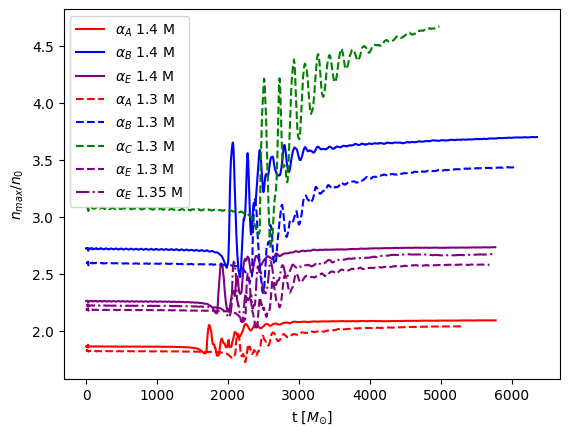

In [41]:
plt.plot(rho_max_a_1p4_t,rho_max_a_1p4,label=r'$\alpha_A$ 1.4 M',color = 'red')
plt.plot(rho_max_b_1p4_t,rho_max_b_1p4,label=r'$\alpha_B$ 1.4 M',color = 'blue')
# plt.plot(rho_max_c_1p4_t,rho_max_c_1p4,label=r'$\alpha_C$ 1.4 M',color = 'green')
# plt.plot(rho_max_d_1p4_t,rho_max_d_1p4,label=r'$\alpha_D$ 1.4 M', color = 'black')
plt.plot(rho_max_e_1p4_t,rho_max_e_1p4,label=r'$\alpha_E$ 1.4 M',color='Purple')

plt.plot(rho_max_a_1p3_t,rho_max_a_1p3,label=r'$\alpha_A$ 1.3 M',color = 'red',linestyle='--')
plt.plot(rho_max_b_1p3_t,rho_max_b_1p3,label=r'$\alpha_B$ 1.3 M',color='blue',linestyle='--')
plt.plot(rho_max_c_1p3_t,rho_max_c_1p3,label=r'$\alpha_C$ 1.3 M',color='green',linestyle='--')
# plt.plot(rho_max_d_1p3_t,rho_max_d_1p3,label=r'$\alpha_D$ 1.3 M',color = 'black',linestyle='--')
plt.plot(rho_max_e_1p3_t,rho_max_e_1p3,label=r'$\alpha_E$ 1.3 M',color = 'purple',linestyle = '--')

plt.plot(rho_max_e_1p35_t,rho_max_e_1p35,label=r'$\alpha_E$ 1.35 M',color = 'purple',linestyle = '-.')


plt.legend()
plt.xlabel(r't [$M_{\odot}$]')
plt.ylabel(r'$n_{max}/n_0$')

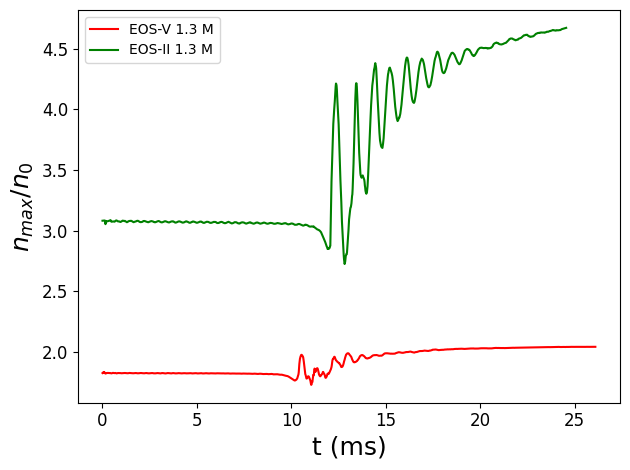

In [46]:
rho_max_fig,rho_max_axes=plt.subplots(1)
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 20

rho_max_axes.plot(np.asarray(rho_max_a_1p3_t)*1/203,rho_max_a_1p3,label=r'EOS-V 1.3 M',color = 'red')
rho_max_axes.plot(np.asarray(rho_max_c_1p3_t)*1/203,rho_max_c_1p3,label=r'EOS-II 1.3 M',color='green')
rho_max_axes.legend()
rho_max_axes.set_xlabel(r't (ms)',fontsize=axes_label_fontsize)
rho_max_axes.set_ylabel(r'$n_{max}/n_0$',fontsize=axes_label_fontsize)
rho_max_axes.tick_params(labelsize=tick_label_fontsize)
rho_max_fig.tight_layout()
rho_max_fig.savefig('./Figures/Final_Paper_Figs/rhomax_bns.pdf',format='pdf',dpi=300)

In [56]:
alpha_A_ejecta_dir_1p3 = '/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M'
alpha_B_ejecta_dir_1p3 = '/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M'
alpha_C_ejecta_dir_1p3 = '/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M'
alpha_D_ejecta_dir_1p3 = '/mnt/John_Backup/RVSS Data/Model_D/1p3M_1p3M'
alpha_E_ejecta_dir_1p3 = '/mnt/John_Backup/RVSS Data/Model_E/1p3M'

alpha_A_ejecta_dir_1p4 = '/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M'
alpha_B_ejecta_dir_1p4 = '/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M'
alpha_C_ejecta_dir_1p4 = '/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M'
alpha_D_ejecta_dir_1p4 = '/mnt/John_Backup/RVSS Data/Model_D/1p4M_1p4M'
alpha_E_ejecta_dir_1p4 = '/mnt/John_Backup/RVSS Data/Model_E/1p4M'

alpha_E_ejecta_dir_1p35 = '/mnt/John_Backup/RVSS Data/Model_E/1p35M'

In [57]:
with open(os.path.join(alpha_C_ejecta_dir_1p3,f'hist_vel_inf_det0.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    print(float(line_split[5]))

0.00363228


In [58]:
r_det = [200,300,400,500]

In [67]:
alpha_A_vel_1p3 = []
alpha_A_theta_1p3 = []
alpha_A_Mej_1p3 = []
alpha_A_Mej_shock_1p3 = []

alpha_B_vel_1p3 = []
alpha_B_theta_1p3 = []
alpha_B_Mej_1p3 = []
alpha_B_Mej_shock_1p3 = []

alpha_C_vel_1p3 = []
alpha_C_theta_1p3 = []
alpha_C_Mej_1p3 = []
alpha_C_Mej_shock_1p3 = []

alpha_D_vel_1p3 = []
alpha_D_theta_1p3 = []
alpha_D_Mej_1p3 = []
alpha_D_Mej_shock_1p3 = []

alpha_E_vel_1p3 = []
alpha_E_theta_1p3 = []
alpha_E_Mej_1p3 = []
alpha_E_Mej_shock_1p3 = []

alpha_A_vel_1p4 = []
alpha_A_theta_1p4 = []
alpha_A_Mej_1p4 = []
alpha_A_Mej_shock_1p4 = []

alpha_B_vel_1p4 = []
alpha_B_theta_1p4 = []
alpha_B_Mej_1p4 = []
alpha_B_Mej_shock_1p4 = []

alpha_C_vel_1p4 = []
alpha_C_theta_1p4 = []
alpha_C_Mej_1p4 = []
alpha_C_Mej_shock_1p4 = []

alpha_D_vel_1p4 = []
alpha_D_theta_1p4 = []
alpha_D_Mej_1p4 = []
alpha_D_Mej_shock_1p4 = []

alpha_E_vel_1p4 = []
alpha_E_theta_1p4 = []
alpha_E_Mej_1p4 = []
alpha_E_Mej_shock_1p4 = []

alpha_E_vel_1p35 = []
alpha_E_theta_1p35 = []
alpha_E_Mej_1p35 = []
alpha_E_Mej_shock_1p35 = []

for id in range(0,4):
    print('here')
    alpha_A_vel_1p3.append(np.loadtxt(os.path.join(alpha_A_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt'),comments='#'))
    #alpha_A_theta_1p3.append(np.loadtxt(os.path.join(alpha_A_ejecta_dir_1p3,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_A_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_A_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_a_1p3_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_A_Mej_shock_1p3.append(alpha_a_1p3_v_inf_ej)
    print('here')
    alpha_B_vel_1p3.append(np.loadtxt(os.path.join(alpha_B_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_B_theta_1p3.append(np.loadtxt(os.path.join(alpha_B_ejecta_dir_1p3,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_B_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_B_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_b_1p3_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_B_Mej_shock_1p3.append(alpha_b_1p3_v_inf_ej)
    print('here')
    alpha_C_vel_1p3.append(np.loadtxt(os.path.join(alpha_C_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_C_theta_1p3.append(np.loadtxt(os.path.join(alpha_C_ejecta_dir_1p3,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_C_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_C_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_c_1p3_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_C_Mej_shock_1p3.append(alpha_c_1p3_v_inf_ej)
    print('here')
    alpha_D_vel_1p3.append(np.loadtxt(os.path.join(alpha_D_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_D_theta_1p3.append(np.loadtxt(os.path.join(alpha_D_ejecta_dir_1p3,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_D_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_D_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_d_1p3_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_D_Mej_shock_1p3.append(alpha_d_1p3_v_inf_ej)
    alpha_E_vel_1p3.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_E_theta_1p3.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p3,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_E_ejecta_dir_1p3,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_E_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_e_1p3_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_E_Mej_shock_1p3.append(alpha_d_1p3_v_inf_ej)
    
for id in range(0,4):
    alpha_A_vel_1p4.append(np.loadtxt(os.path.join(alpha_A_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_A_theta_1p4.append(np.loadtxt(os.path.join(alpha_A_ejecta_dir_1p4,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_A_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_A_Mej_1p4.append(float(line_split[5]))
                    break
        alpha_a_1p4_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_A_Mej_shock_1p4.append(alpha_a_1p4_v_inf_ej)
                
    print('here')
    alpha_B_vel_1p3.append(np.loadtxt(os.path.join(alpha_B_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_B_theta_1p3.append(np.loadtxt(os.path.join(alpha_B_ejecta_dir_1p4,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_B_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_B_Mej_1p4.append(float(line_split[5]))
                    break
        alpha_b_1p4_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_B_Mej_shock_1p4.append(alpha_b_1p4_v_inf_ej)
    print('here')
    alpha_C_vel_1p4.append(np.loadtxt(os.path.join(alpha_C_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_C_theta_1p4.append(np.loadtxt(os.path.join(alpha_C_ejecta_dir_1p4,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_C_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_C_Mej_1p4.append(float(line_split[5]))
                    break
        alpha_c_1p4_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_C_Mej_shock_1p4.append(alpha_c_1p4_v_inf_ej)
    print('here')
    alpha_D_vel_1p4.append(np.loadtxt(os.path.join(alpha_D_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_D_theta_1p4.append(np.loadtxt(os.path.join(alpha_D_ejecta_dir_1p4,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_D_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_D_Mej_1p4.append(float(line_split[5]))
                    break
        alpha_d_1p4_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_D_Mej_shock_1p4.append(alpha_d_1p4_v_inf_ej)

    alpha_E_vel_1p4.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_E_theta_1p4.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p4,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_E_ejecta_dir_1p4,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_E_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_e_1p4_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_E_Mej_shock_1p4.append(alpha_d_1p4_v_inf_ej)

    alpha_E_vel_1p35.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p35,f'hist_vel_inf_det{id}.txt'),comments='#'))
    alpha_E_theta_1p35.append(np.loadtxt(os.path.join(alpha_E_ejecta_dir_1p35,f'hist_theta_det{id}.txt'),comments='#'))
    with open(os.path.join(alpha_E_ejecta_dir_1p35,f'hist_vel_inf_det{id}.txt')) as file:
        for line in file:
            if line.startswith('#'):
                line_split = line.split(' ')
                if(line_split[1] == 'Total'):
                    alpha_E_Mej_1p3.append(float(line_split[5]))
                    break
        alpha_e_1p35_v_inf_ej = np.loadtxt(file,skiprows=2)
        alpha_E_Mej_shock_1p35.append(alpha_e_1p35_v_inf_ej)


here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here
here


In [74]:
#Calculate Alpha A M_ej shock for 1.3M - 1.3M
alpha_a_m_shock_1p3 = 0
for id,data in enumerate(alpha_A_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_a_m_shock_1p3 += d[1]
alpha_a_m_shock_1p3 = alpha_a_m_shock_1p3/4

#Calculate Alpha A M_ej shock for 1.4M - 1.4M
alpha_a_m_shock_1p4 = 0
for id,data in enumerate(alpha_A_Mej_shock_1p4):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_a_m_shock_1p4 += d[1]
alpha_a_m_shock_1p4 = alpha_a_m_shock_1p4/4

#Calculate Alpha B M_ej shock for 1.3M - 1.3M
alpha_b_m_shock_1p3 = 0
for id,data in enumerate(alpha_B_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_b_m_shock_1p3 += d[1]
alpha_b_m_shock_1p3 = alpha_b_m_shock_1p3/4

#Calculate Alpha B M_ej shock for 1.4M - 1.4M
alpha_b_m_shock_1p4 = 0
for id,data in enumerate(alpha_B_Mej_shock_1p4):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_b_m_shock_1p4 += d[1]
alpha_b_m_shock_1p4 = alpha_b_m_shock_1p4/4

#Calculate Alpha C M_ej shock for 1.3M - 1.3M
alpha_c_m_shock_1p3 = 0
for id,data in enumerate(alpha_C_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_c_m_shock_1p3 += d[1]
alpha_c_m_shock_1p3 = alpha_c_m_shock_1p3/4

#Calculate Alpha C M_ej shock for 1.4M - 1.4M
alpha_c_m_shock_1p4 = 0
for id,data in enumerate(alpha_C_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_c_m_shock_1p4 += d[1]
alpha_c_m_shock_1p4 = alpha_c_m_shock_1p4/4

#Calculate Alpha D M_ej shock for 1.3M - 1.3M
alpha_d_m_shock_1p3 = 0
for id,data in enumerate(alpha_D_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_d_m_shock_1p3 += d[1]
alpha_d_m_shock_1p3 = alpha_d_m_shock_1p3/4

#Calculate Alpha D M_ej shock for 1.4M - 1.4M
alpha_d_m_shock_1p4 = 0
for id,data in enumerate(alpha_D_Mej_shock_1p4):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_d_m_shock_1p4 += d[1]
alpha_d_m_shock_1p4 = alpha_d_m_shock_1p4/4

#Calculate Alpha E M_ej shock for 1.3M - 1.3M
alpha_e_m_shock_1p3 = 0
for id,data in enumerate(alpha_E_Mej_shock_1p3):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_e_m_shock_1p3 += d[1]
alpha_e_m_shock_1p3 = alpha_d_m_shock_1p3/4

alpha_e_m_shock_1p4 = 0
for id,data in enumerate(alpha_E_Mej_shock_1p4):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_e_m_shock_1p4 += d[1]

alpha_e_m_shock_1p35 = 0
for id,data in enumerate(alpha_E_Mej_shock_1p35):

    for i,d in enumerate(data):
        if(d[0] > 0.6):
            alpha_e_m_shock_1p35 += d[1]
alpha_d_m_shock_1p3 = alpha_d_m_shock_1p3/4
alpha_e_m_shock_1p3 = alpha_e_m_shock_1p3/4
alpha_e_m_shock_1p4 = alpha_e_m_shock_1p4/4
alpha_e_m_shock_1p35 = alpha_e_m_shock_1p35/4

m_shock_1p3 = [alpha_a_m_shock_1p3,alpha_b_m_shock_1p3,alpha_c_m_shock_1p3,alpha_d_m_shock_1p3,alpha_e_m_shock_1p3]

m_shock_1p4 = [alpha_a_m_shock_1p4,alpha_b_m_shock_1p4,alpha_c_m_shock_1p4,alpha_d_m_shock_1p4,alpha_e_m_shock_1p4]


In [63]:
print(len(alpha_list))
print(len(m_shock_1p4))

5
4


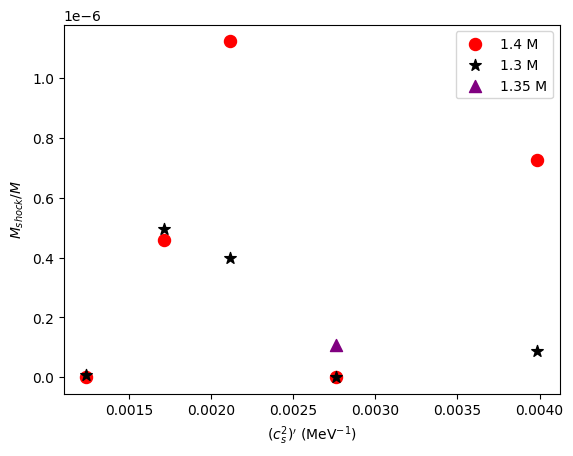

In [82]:
plt.scatter(alpha_list,np.asarray(m_shock_1p4)/(2.8),color='red',marker='o',s=75,label='1.4 M')
plt.scatter(alpha_list_1p3,np.asarray(m_shock_1p3)/(2.6),color = 'black',marker = '*', s = 75,label = '1.3 M')
plt.scatter(alpha_list[-1],alpha_e_m_shock_1p35/(2.7),color='purple',marker='^', s = 75, label= '1.35 M')
plt.xlabel(r"$(c_s^2)'\text{ (MeV}^{-1}$)")
plt.ylabel(r'$M_{shock}/M$')
plt.legend()

np.savetxt('../Figure_Data/GW/Mshock_norm_1p4.txt',np.asarray(list(zip(alpha_list,np.asarray(m_shock_1p4)/(2.8)))))
np.savetxt('../Figure_Data/GW/Mshock_norm_1p3.txt',np.asarray(list(zip(alpha_list_1p3,np.asarray(m_shock_1p3)/(2.6)))))
np.savetxt('../Figure_Data/GW/Mshock_norm_1p35.txt',[alpha_list[-1],(alpha_e_m_shock_1p35)/(2.7)])



In [23]:
print(alpha_a_m_shock_1p3)

2.27153317007281e-07


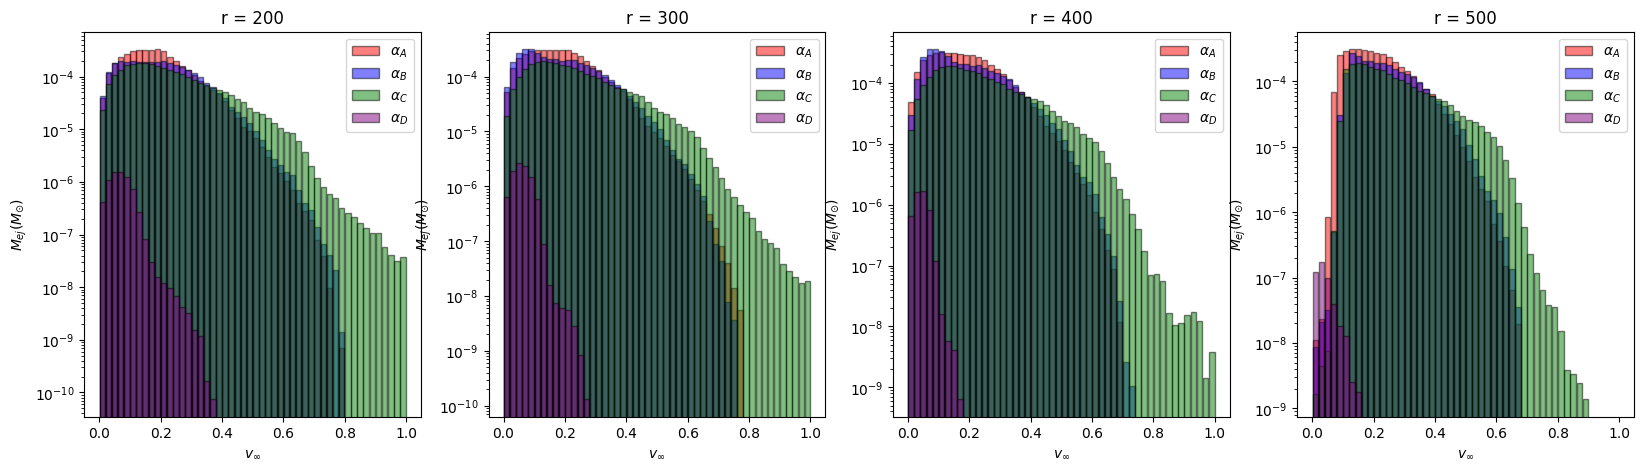

In [46]:
hist_fig,hist_axes = plt.subplots(nrows = 1,ncols=4,figsize=(20,5))
for id in range(0,4):
    alpha_a_vinf = alpha_A_vel[id]
    alpha_a_theta = alpha_A_theta[id]

    alpha_b_vinf = alpha_B_vel[id]
    alpha_b_theta = alpha_B_theta[id]

    alpha_c_vinf = alpha_C_vel[id]
    alpha_c_theta = alpha_C_theta[id]

    alpha_d_vinf = alpha_D_vel[id]
    alpha_d_theta = alpha_D_theta[id]

    hist_axes[id].bar(alpha_a_vinf[:,0],alpha_a_vinf[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'red',label=r'$\alpha_A$',alpha=0.5)
    #hist_axes[1,id].bar(alpha_a_theta[:,0],alpha_a_theta[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'red',label=r'$\alpha_A$')

    hist_axes[id].bar(alpha_b_vinf[:,0],alpha_b_vinf[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'blue',label=r'$\alpha_B$',alpha=0.5)
    #hist_axes[1,id].bar(alpha_b_theta[:,0],alpha_b_theta[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'blue',label=r'$\alpha_B$')

    hist_axes[id].bar(alpha_c_vinf[:,0],alpha_c_vinf[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'green',label=r'$\alpha_C$',alpha=0.5)
    #hist_axes[1,id].bar(alpha_c_theta[:,0],alpha_c_theta[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'green',label=r'$\alpha_C$')

    hist_axes[id].bar(alpha_d_vinf[:,0],alpha_d_vinf[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'purple',label=r'$\alpha_D$',alpha=0.5)
    hist_axes[id].legend()
    hist_axes[id].set_xlabel(r'$v_{\infty}$')
    hist_axes[id].set_ylabel(r'$M_{ej}$($M_{\odot}$)')
    hist_axes[id].set_title(f'r = {r_det[id]}')
    hist_axes[id].set_yscale('log')
    #hist_axes[1,id].bar(alpha_d_theta[:,0],alpha_d_theta[:,1],width = 0.018,align = 'center', edgecolor = 'black',color = 'purple',label=r'$\alpha_D$')

plt.show()

In [69]:
M_ej_det0_1p3 = [alpha_A_Mej_1p3[0],alpha_B_Mej_1p3[0],alpha_C_Mej_1p3[0],alpha_D_Mej_1p3[0]]
M_ej_det1_1p3 = [alpha_A_Mej_1p3[1],alpha_B_Mej_1p3[1],alpha_C_Mej_1p3[1],alpha_D_Mej_1p3[1]]
M_ej_det2_1p3 = [alpha_A_Mej_1p3[2],alpha_B_Mej_1p3[2],alpha_C_Mej_1p3[2],alpha_D_Mej_1p3[2]]
M_ej_det3_1p3 = [alpha_A_Mej_1p3[3],alpha_B_Mej_1p3[3],alpha_C_Mej_1p3[3],alpha_D_Mej_1p3[3]]
M_ej_mat_1p3 = np.row_stack([M_ej_det0_1p3,M_ej_det1_1p3,M_ej_det2_1p3,M_ej_det3_1p3])

M_ej_det0_1p4 = [alpha_A_Mej_1p4[0],alpha_B_Mej_1p4[0],alpha_C_Mej_1p4[0],alpha_D_Mej_1p4[0]]
M_ej_det1_1p4 = [alpha_A_Mej_1p4[1],alpha_B_Mej_1p4[1],alpha_C_Mej_1p4[1],alpha_D_Mej_1p4[1]]
M_ej_det2_1p4 = [alpha_A_Mej_1p4[2],alpha_B_Mej_1p4[2],alpha_C_Mej_1p4[2],alpha_D_Mej_1p4[2]]
M_ej_det3_1p4 = [alpha_A_Mej_1p4[3],alpha_B_Mej_1p4[3],alpha_C_Mej_1p4[3],alpha_D_Mej_1p4[3]]
M_ej_mat_1p4 = np.row_stack([M_ej_det0_1p4,M_ej_det1_1p4,M_ej_det2_1p4,M_ej_det3_1p4])

alpha_a_avg_ej_1p3 = np.average(M_ej_mat_1p3[:,0])
alpha_b_avg_ej_1p3 = np.average(M_ej_mat_1p3[:,1])
alpha_c_avg_ej_1p3 = np.average(M_ej_mat_1p3[:,2])
alpha_d_avg_ej_1p3 = np.average(M_ej_mat_1p3[:,3])

alpha_a_avg_ej_1p4 = np.average(M_ej_mat_1p4[:,0])
alpha_b_avg_ej_1p4 = np.average(M_ej_mat_1p4[:,1])
alpha_c_avg_ej_1p4 = np.average(M_ej_mat_1p4[:,2])
alpha_d_avg_ej_1p4 = np.average(M_ej_mat_1p4[:,3])

avg_ejecta_1p3 = [alpha_a_avg_ej_1p3,alpha_b_avg_ej_1p3,alpha_c_avg_ej_1p3,alpha_d_avg_ej_1p3]
avg_ejecta_1p4 = [alpha_a_avg_ej_1p4,alpha_b_avg_ej_1p4,alpha_c_avg_ej_1p4,alpha_d_avg_ej_1p4]

print(alpha_a_avg_ej_1p3)
print(alpha_b_avg_ej_1p3)
print(alpha_c_avg_ej_1p3)
print(alpha_d_avg_ej_1p3)

print(alpha_a_avg_ej_1p4)
print(alpha_b_avg_ej_1p4)
print(alpha_c_avg_ej_1p4)
print(alpha_d_avg_ej_1p4)

0.001646295
0.00143263925
0.0029482875
6.116055e-05
0.0038478375
0.0030475525
0.00245045
5.503709e-06


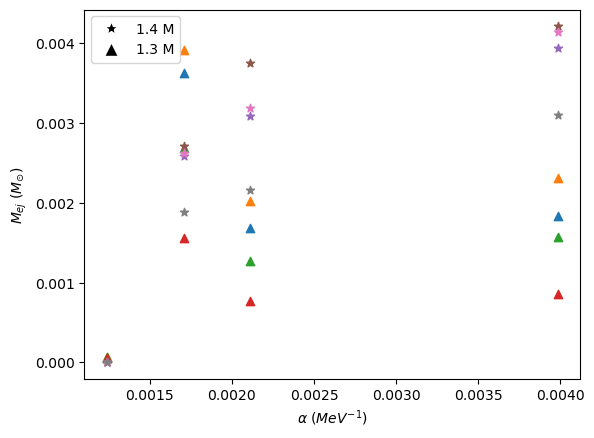

In [70]:
plt.scatter(alpha_list_1p3,M_ej_det0_1p3,label='R = 200 1.3 M',marker='^')
plt.scatter(alpha_list_1p3,M_ej_det1_1p3,label='R = 300 1.3 M',marker='^')
plt.scatter(alpha_list_1p3,M_ej_det2_1p3,label='R = 400 1.3 M',marker='^')
plt.scatter(alpha_list_1p3,M_ej_det3_1p3,label='R = 500 1.3 M',marker='^')

plt.scatter(alpha_list,M_ej_det0_1p4,label='R = 200 1.4 M',marker='*')
plt.scatter(alpha_list,M_ej_det1_1p4,label='R = 300 1.4 M',marker='*')
plt.scatter(alpha_list,M_ej_det2_1p4,label='R = 400 1.4 M',marker='*')
plt.scatter(alpha_list,M_ej_det3_1p4,label='R = 500 1.4 M',marker='*')
plt.xlabel(r'$\alpha$ ($MeV^{-1}$)')
plt.ylabel(r'$M_{ej}$ ($M_{\odot}$)')
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markersize=10, label='1.4 M'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=10, label='1.3 M')
]

# Add legend with only the two types
plt.legend(handles=legend_elements)
#plt.yscale('log')

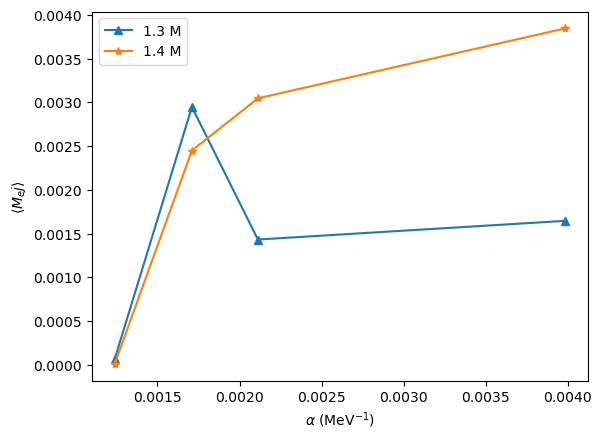

In [72]:
plt.plot(alpha_list_1p3,avg_ejecta_1p3,label='1.3 M',marker='^')
plt.plot(alpha_list,avg_ejecta_1p4,label='1.4 M',marker='*')
plt.xlabel(r'$\alpha$ ($\text{MeV}^{-1}$)')
plt.ylabel(r'$\langle M_ej \rangle$')
plt.legend()

In [111]:
alpha_a_total_e = alpha_a_energy.y[np.argmax(alpha_a_energy.t == t_cut)]
alpha_b_total_e = alpha_b_energy.y[np.argmax(alpha_b_energy.t == t_cut)]
alpha_c_total_e = alpha_c_energy.y[np.argmax(alpha_c_energy.t == t_cut)]
alpha_d_total_e = alpha_d_engergy.y[np.argmax(alpha_d_engergy.t == t_cut)]
total_e = [alpha_a_total_e,alpha_b_total_e,alpha_c_total_e,alpha_d_total_e]

In [112]:
alpha_a_total_Lz = alpha_a_ang_mom.y[np.argmax(alpha_a_ang_mom.t == t_cut)]
alpha_b_total_Lz = alpha_b_ang_mom.y[np.argmax(alpha_b_ang_mom.t == t_cut)]
alpha_c_total_Lz = alpha_c_ang_mom.y[np.argmax(alpha_c_ang_mom.t == t_cut)]
alpha_d_total_Lz = alpha_d_ang_mom.y[np.argmax(alpha_d_ang_mom.t == t_cut)]
total_Lz = [alpha_a_total_Lz,alpha_b_total_Lz,alpha_c_total_Lz,alpha_d_total_Lz]

Text(0, 0.5, '$E_{GW}$ $(M_{\\odot}$)')

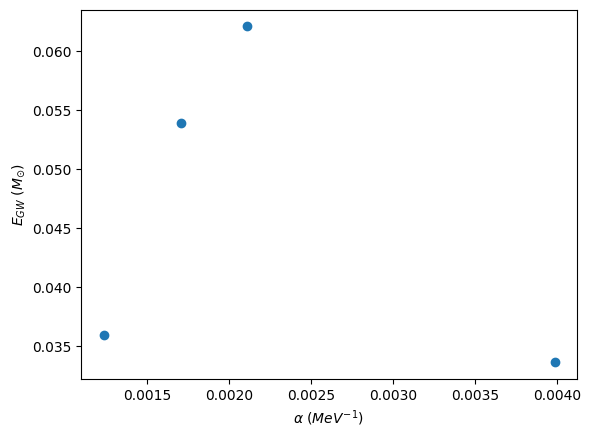

In [113]:
plt.scatter(alpha_list,total_e)
plt.xlabel(r'$\alpha$ $(MeV^{-1})$ ')
plt.ylabel(r'$E_{GW}$ $(M_{\odot}$)')

Text(0, 0.5, '$L_z (M_{\\odot}^2)$')

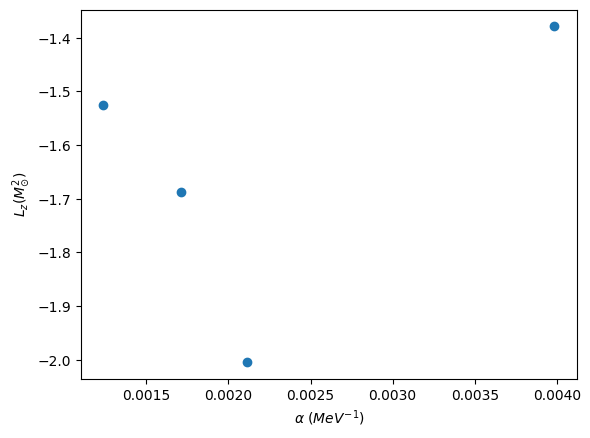

In [116]:
plt.scatter(alpha_list,total_Lz)
plt.xlabel(r'$\alpha$ $(MeV^{-1})$')
plt.ylabel(r'$L_z (M_{\odot}^2)$')